In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math
import matplotlib.cm as cm
import os

In [5]:
def concat_dfs(heuristic, types):
    dfs = []
    
    for t in types:
        file_path = f"./output/{heuristic}/{t}/output.csv"
        try:
            df = pd.read_csv(file_path)
            df["type"] = t
            df["algorithm"] = heuristic
            dfs.append(df)
        except FileNotFoundError:
            print(f"File not found: {file_path}")
            df = None 
    
    final_df = pd.concat(dfs, ignore_index=True)
    return final_df

In [202]:
def compare_obj_value_time_for_diff_algorithm_types_subplots(df_all, name, filter_nreq, legend_col, display_by_column=None, display_by_column_value=None):

    if filter_nreq:
        df_all = df_all[df_all['nreq'] == filter_nreq]
    append_titel=""
    if display_by_column and display_by_column_value:
        df_all = df_all[df_all[display_by_column] == display_by_column_value]
        append_titel = f"{display_by_column}_{display_by_column_value}"
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

    metrics = [
        ("avg_obj_func", "Average Objective Function"),
        ("avg_time", "Average Time")
    ]

    for ax, (value, label_part) in zip(axes, metrics):
        for t in df_all[legend_col].unique():
            subset = df_all[df_all[legend_col] == t]
            ax.plot(
                subset["number"],
                subset[value],
                marker=".",
                linestyle="-",
                label=t
            )
        
        ax.set_xlabel("Instance")
        ax.set_ylabel(label_part)
        ax.set_title(f"{name} {append_titel}: {label_part} by {legend_col}")
        ax.legend(title=legend_col.title())

    plt.tight_layout()
    plt.show()

In [134]:
def compare_obj_value_time_for_diff_algorithm_types_boxplots(df_all, name, legend_col, display_by_column=None, display_by_column_value=None):
    """
    Create boxplots of avg_obj_func and avg_time for different 'nreq' and algorithm types.
    """
    df_plot = df_all.copy()
    
    append_title = ""
    if display_by_column and display_by_column_value:
        df_plot = df_plot[df_plot[display_by_column] == display_by_column_value]
        append_title = f"{display_by_column}_{display_by_column_value}"

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # Metrics to plot
    metrics = [
        ("avg_obj_func", "Average Objective Function"),
        ("avg_time", "Average Time")
    ]
    
    for ax, (metric, ylabel) in zip(axes, metrics):
        sns.boxplot(
            x="nreq",
            y=metric,
            hue=legend_col,
            data=df_plot,
            ax=ax
        )
        ax.set_xlabel("Number of Customers")
        ax.set_ylabel(ylabel)
        ax.set_title(f"{name} {append_title}: {ylabel} by Number of Customers")
        ax.legend(title=legend_col.title())

    plt.tight_layout()
    plt.show()

## Construction Heuristic

In [135]:
df_construction = concat_dfs("c", ["pure", "with_reordering"])
display(df_construction)

,number,nreq,nveh,to_fulfilled,rho,avg_time,avg_obj_func,iterations,type,algorithm
0,1,50,2,50,25.94,0.081947,3812.26,48.0,pure,c
1,2,50,2,45,35.31,0.079431,3497.01,46.0,pure,c
2,3,50,2,45,41.17,0.070122,3442.89,43.0,pure,c
3,4,50,2,47,70.70,0.065885,3639.79,45.0,pure,c
4,5,50,2,45,54.30,0.078604,3506.35,43.0,pure,c
...,...,...,...,...,...,...,...,...,...,...
115,26,100,2,89,64.14,7.835079,4098.49,88.0,with_reordering,c
116,27,100,2,91,25.94,7.305212,4030.94,89.0,with_reordering,c
117,28,100,2,91,37.19,7.877806,4119.43,92.0,with_reordering,c
118,29,100,2,96,52.11,10.414334,4643.58,95.0,with_reordering,c


In [136]:
grouped = df_construction[df_construction["nreq"] == 100].groupby("type")

# compute statistics
summary = grouped.agg(
    best_obj=("avg_obj_func", "min"),
    mean_obj=("avg_obj_func", "mean"),
    std_obj=("avg_obj_func", "std"),

    best_time=("avg_time", "min"),
    mean_time=("avg_time", "mean"),
    std_time=("avg_time", "std"),

    runs=("avg_obj_func", "count")
)

display(summary)

,best_obj,mean_obj,std_obj,best_time,mean_time,std_time,runs
type,,,,,,,
pure,8090.95,9285.953000,463.704487,0.430435,0.482863,0.050588,30
with_reordering,3761.91,4120.235667,208.807167,5.335639,7.265673,1.237071,30


### Compare Average Objective Funciton, Run Time for 100 customers

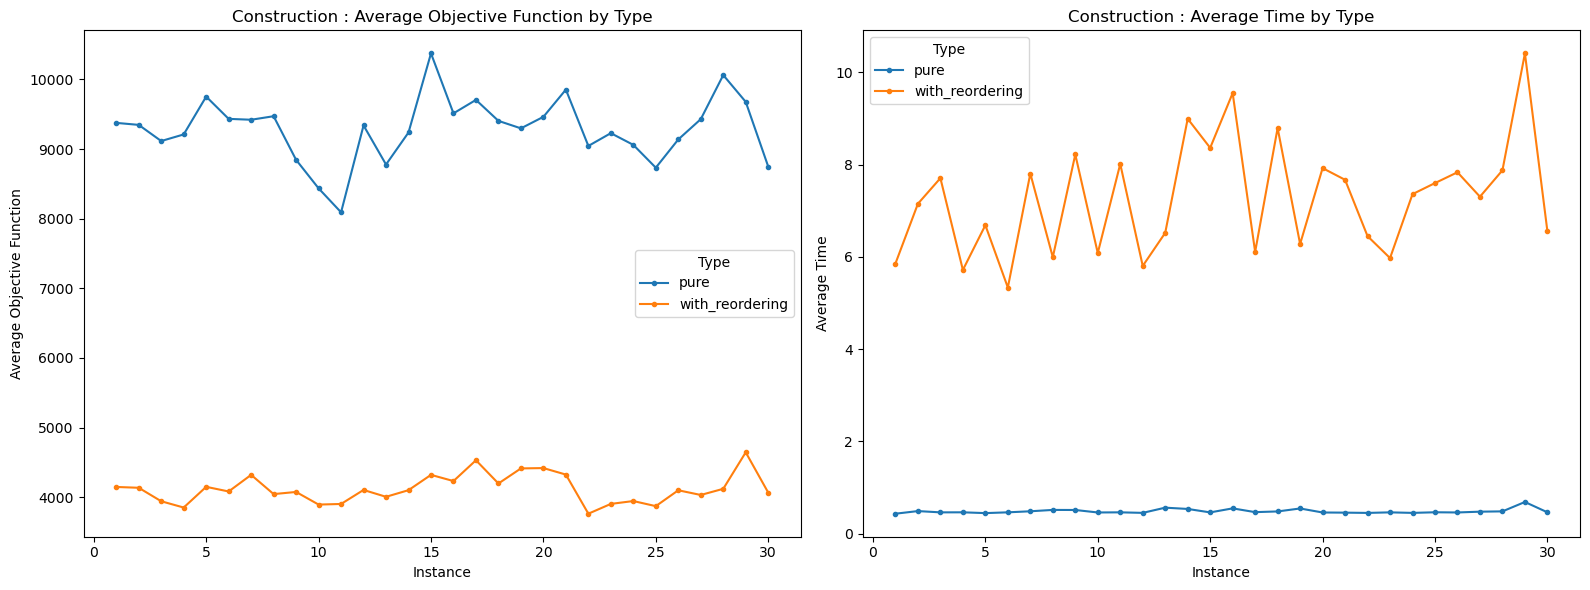

In [10]:
compare_obj_value_time_for_diff_algorithm_types_subplots(df_construction, "Construction", 100, "type")

### Compare Average Objective Funciton, Run Time for different number of customers

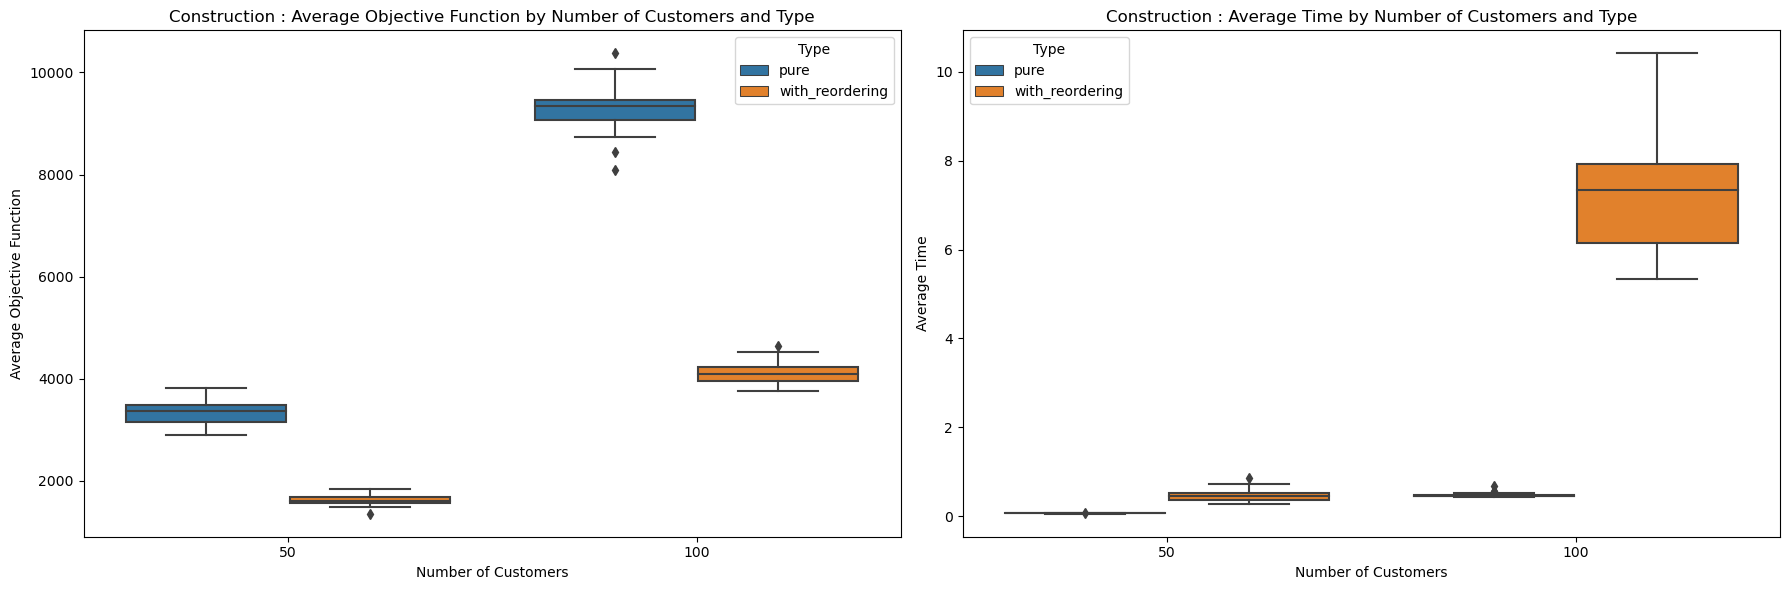

In [11]:
compare_obj_value_time_for_diff_algorithm_types_boxplots(df_construction, "Construction", "type")

## Randomized Construction heuristic

In [12]:
df_construction_random = concat_dfs("rc", ["pure", "with_reordering"])
display(df_construction_random)

,number,nreq,nveh,to_fulfilled,rho,avg_time,avg_obj_func,iterations,type,algorithm
0,1,50,2,50,25.94,0.079391,3844.392,48.0,pure,rc
1,2,50,2,45,35.31,0.066643,3372.258,43.0,pure,rc
2,3,50,2,45,41.17,0.063883,3394.650,43.0,pure,rc
3,4,50,2,47,70.70,0.067669,3722.448,45.0,pure,rc
4,5,50,2,45,54.30,0.067524,3559.084,43.0,pure,rc
...,...,...,...,...,...,...,...,...,...,...
115,26,100,2,89,64.14,8.328909,4011.530,87.4,with_reordering,rc
116,27,100,2,91,25.94,8.638492,3984.240,89.2,with_reordering,rc
117,28,100,2,91,37.19,7.951354,4365.270,89.0,with_reordering,rc
118,29,100,2,96,52.11,10.966496,4448.774,94.2,with_reordering,rc


### Compare Average Objective Funciton, Run Time for 100 customers

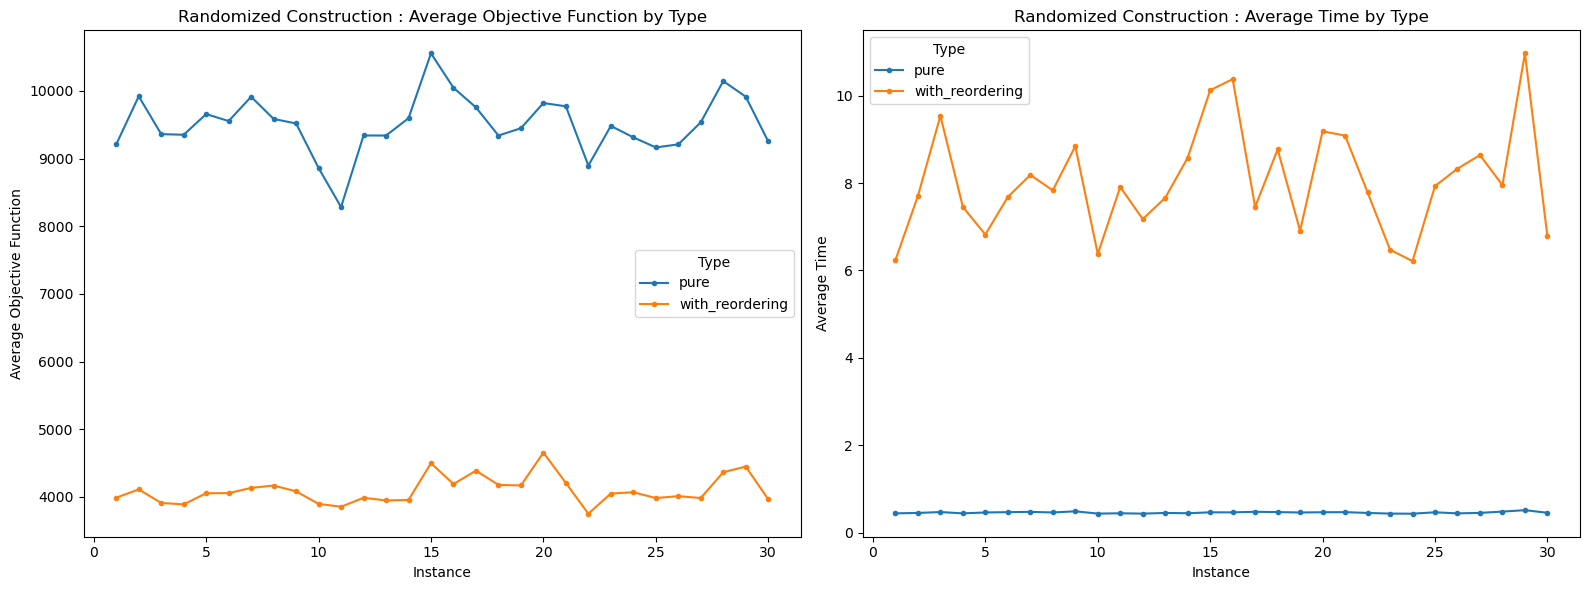

In [19]:
compare_obj_value_time_for_diff_algorithm_types_subplots(df_construction_random, "Randomized Construction", 100, "type")

### Compare Average Objective Funciton, Run Time for 100 customers

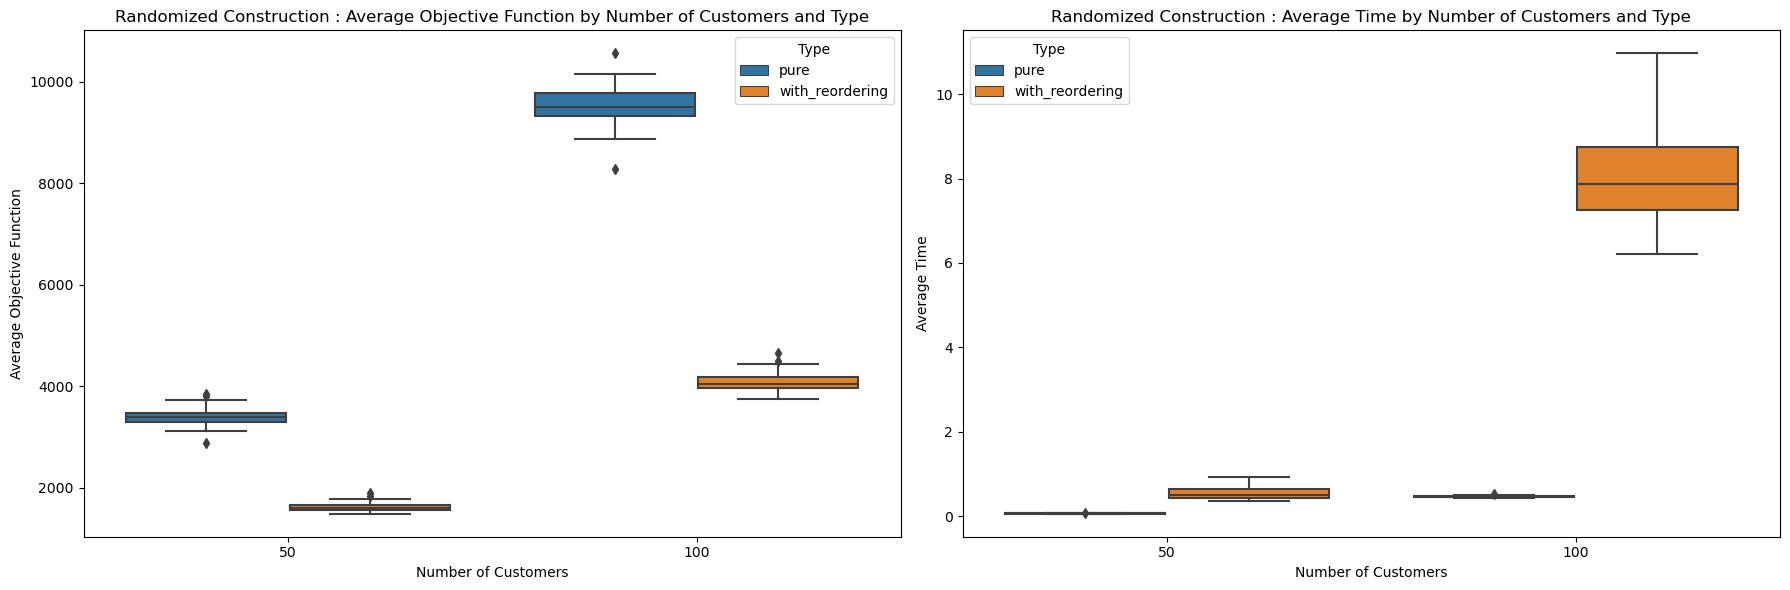

In [15]:
compare_obj_value_time_for_diff_algorithm_types_boxplots(df_construction_random, "Randomized Construction", "type")

### Compare Average Objective Funciton: degree of randomization (with reordering)

In [43]:
df_construction_random_3 = concat_dfs("rc/alpha_0.3", ["pure", "with_reordering"])
df_construction_random_3 = df_construction_random_3[df_construction_random_3["type"] == "with_reordering"]
df_construction_random_3["degree of randomization"] = "0.3"

df_construction_random_5 = concat_dfs("rc/alpha_0.5", ["pure", "with_reordering"])
df_construction_random_5 = df_construction_random_5[df_construction_random_5["type"] == "with_reordering"]
df_construction_random_5["degree of randomization"] = "0.5"

df_construction_random_8 = concat_dfs("rc/alpha_0.8", ["pure", "with_reordering"])
df_construction_random_8 = df_construction_random_8[df_construction_random_8["type"] == "with_reordering"]
df_construction_random_8["degree of randomization"] = "0.8"

df_combined = pd.concat([df_construction_random_3, df_construction_random_5, df_construction_random_8], ignore_index=True)
display(df_combined)

,number,nreq,nveh,to_fulfilled,rho,avg_time,avg_obj_func,iterations,type,algorithm,degree of randomization
0,1,100,2,98,42.27,33.926269,4190.74,96.0,with_reordering,rc/alpha_0.3,0.3
1,2,100,2,88,44.45,22.334355,4200.60,86.0,with_reordering,rc/alpha_0.3,0.3
2,3,100,2,91,52.11,24.458363,4097.55,89.0,with_reordering,rc/alpha_0.3,0.3
3,4,100,2,89,24.06,21.968577,4579.84,87.0,with_reordering,rc/alpha_0.3,0.3
4,5,100,2,94,79.73,26.409159,4351.06,92.0,with_reordering,rc/alpha_0.3,0.3
...,...,...,...,...,...,...,...,...,...,...,...
175,26,50,2,47,27.81,1.712008,1877.61,45.0,with_reordering,rc/alpha_0.8,0.8
176,27,50,2,43,29.69,1.717079,1583.29,41.0,with_reordering,rc/alpha_0.8,0.8
177,28,50,2,41,37.19,1.677777,1590.67,39.0,with_reordering,rc/alpha_0.8,0.8
178,29,50,2,45,80.90,1.833201,1697.63,43.0,with_reordering,rc/alpha_0.8,0.8


In [44]:
print(df_combined["degree of randomization"].unique())

['0.3' '0.5' '0.8']


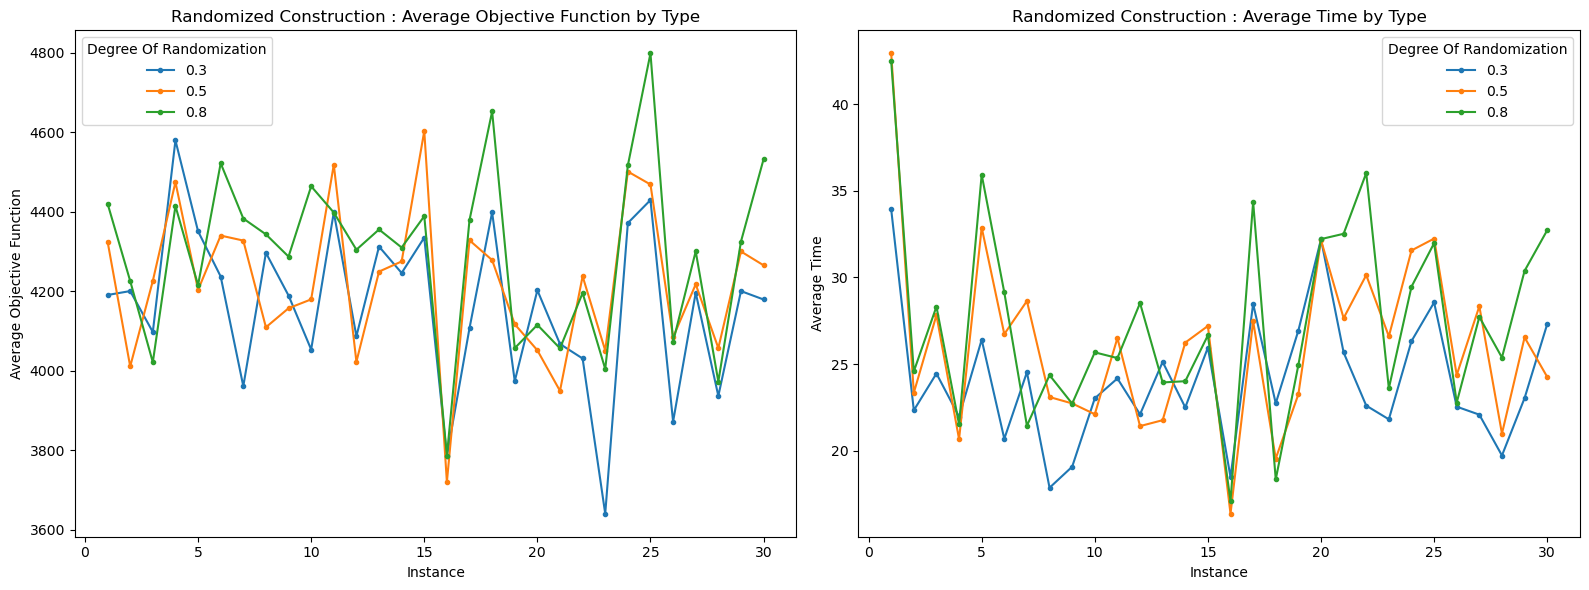

In [45]:
compare_obj_value_time_for_diff_algorithm_types_subplots(df_combined, "Randomized Construction", 100, "degree of randomization")

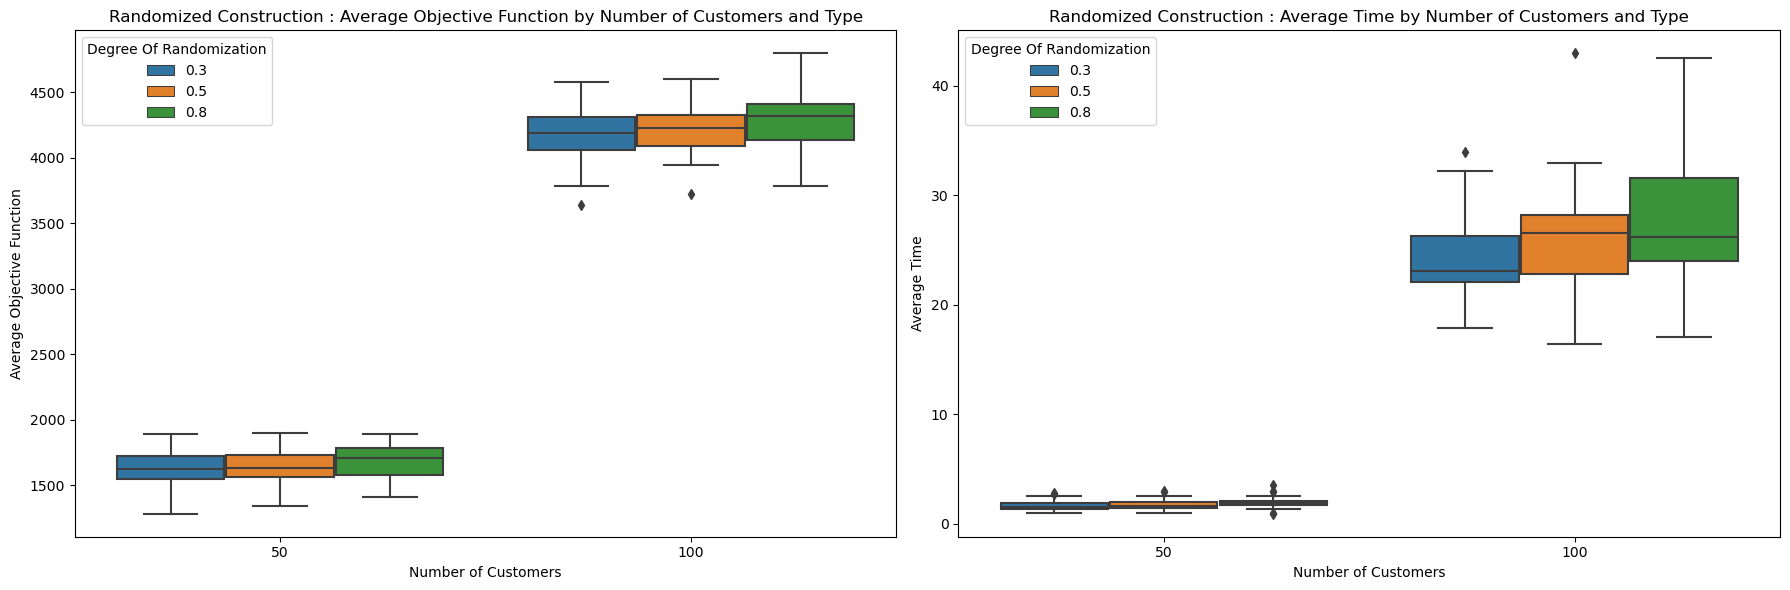

In [47]:
compare_obj_value_time_for_diff_algorithm_types_boxplots(df_combined, "Randomized Construction", "degree of randomization")

In [149]:
file_path = f"./results/ps/output.csv"
df_ps = pd.read_csv(file_path)
df_ps["type"] = None
df_ps["algorithm"] = "ps"
display(df_ps)

,number,nreq,nveh,to_fulfilled,rho,avg_time,avg_obj_func,iterations,type,algorithm
0,1,50,2,50,25.94,198.878243,467.06,50.0,None,ps
1,2,50,2,45,35.31,131.369979,468.82,45.0,None,ps
2,3,50,2,45,41.17,166.637003,1207.34,45.0,None,ps
3,4,50,2,47,70.70,168.961202,518.94,47.0,None,ps
4,5,50,2,45,54.30,123.604001,645.80,45.0,None,ps
5,6,50,2,46,42.27,119.923308,366.92,46.0,None,ps
6,7,50,2,45,25.94,201.521106,1437.20,45.0,None,ps
7,8,50,2,43,68.52,96.245780,586.81,43.0,None,ps
8,9,50,2,43,66.33,186.288152,631.72,43.0,None,ps
9,10,50,2,46,25.94,107.909041,561.81,46.0,None,ps


In [141]:
df_construction_filtered = df_construction[
    (df_construction['nreq'] == 50) & 
    (df_construction['type'] == "pure")
]
display(df_construction_filtered)

,number,nreq,nveh,to_fulfilled,rho,avg_time,avg_obj_func,iterations,type,algorithm
0,1,50,2,50,25.94,0.081947,3812.26,48.0,pure,c
1,2,50,2,45,35.31,0.079431,3497.01,46.0,pure,c
2,3,50,2,45,41.17,0.070122,3442.89,43.0,pure,c
3,4,50,2,47,70.70,0.065885,3639.79,45.0,pure,c
4,5,50,2,45,54.30,0.078604,3506.35,43.0,pure,c
5,6,50,2,46,42.27,0.070313,3372.43,44.0,pure,c
6,7,50,2,45,25.94,0.061727,3469.58,43.0,pure,c
7,8,50,2,43,68.52,0.059443,3054.06,41.0,pure,c
8,9,50,2,43,66.33,0.060179,3348.88,41.0,pure,c
9,10,50,2,46,25.94,0.065632,2892.47,44.0,pure,c


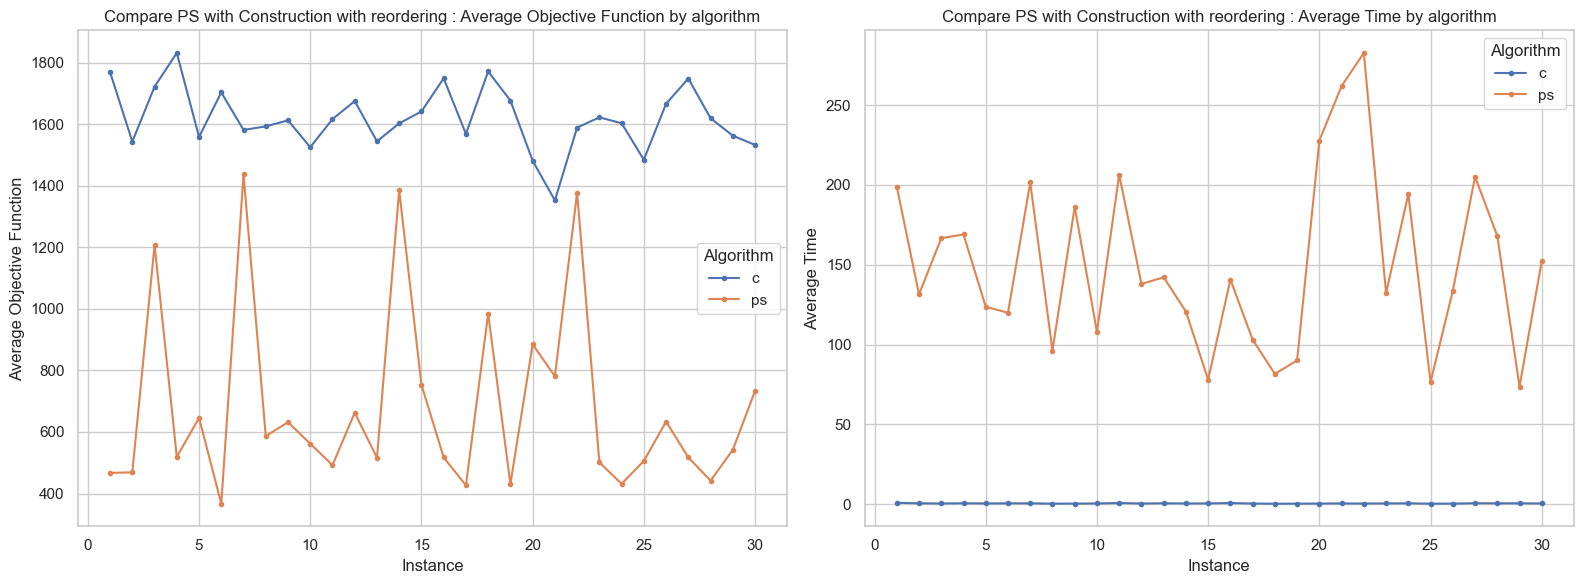

In [150]:
df_const_ps = pd.concat([df_construction_filtered, df_ps], ignore_index=True)
compare_obj_value_time_for_diff_algorithm_types_subplots(df_const_ps, "Compare PS with Construction with reordering", 50, "algorithm")

## Local Search

In [77]:
list_nh = ['exchange', 'pickup_relocate', 'dropoff_relocate', 'remove_and_append', 'move']
list_str = ['best', 'first']

In [78]:
list_nh = ['exchange', 'pickup_relocate', 'dropoff_relocate', 'remove_and_append', 'move']
list_str = ['best', 'first']
df_ls = concat_dfs("ls", [f"{nh}_{s}" for nh in list_nh for s in list_str])
df_ls[["neighborhood structures", "strategy"]] = df_ls["type"].str.rsplit("_", n=1, expand=True)
#df_ls["strategy"] = df_ls["strategy"].map({"best": "first", "first": "best"})
display(df_ls)

,number,nreq,nveh,to_fulfilled,rho,avg_time,avg_obj_func,iterations,type,algorithm,neighborhood structures,strategy
0,1,50,2,50,25.94,0.053217,1768.84,1.0,exchange_best,ls,exchange,best
1,2,50,2,45,35.31,0.405862,1370.12,12.0,exchange_best,ls,exchange,best
2,3,50,2,45,41.17,0.283709,1559.21,7.0,exchange_best,ls,exchange,best
3,4,50,2,47,70.70,0.290158,1730.41,4.0,exchange_best,ls,exchange,best
4,5,50,2,45,54.30,0.042777,1558.50,1.0,exchange_best,ls,exchange,best
...,...,...,...,...,...,...,...,...,...,...,...,...
595,26,100,2,89,64.14,140.775048,3662.07,61.0,move_first,ls,move,first
596,27,100,2,91,25.94,33.094001,3745.97,34.0,move_first,ls,move,first
597,28,100,2,91,37.19,21.425843,4083.59,4.0,move_first,ls,move,first
598,29,100,2,96,52.11,60.639150,4022.05,71.0,move_first,ls,move,first


### Compare Average Objective Funciton, Run Time for 50 customers: Different Neighborhood Structures

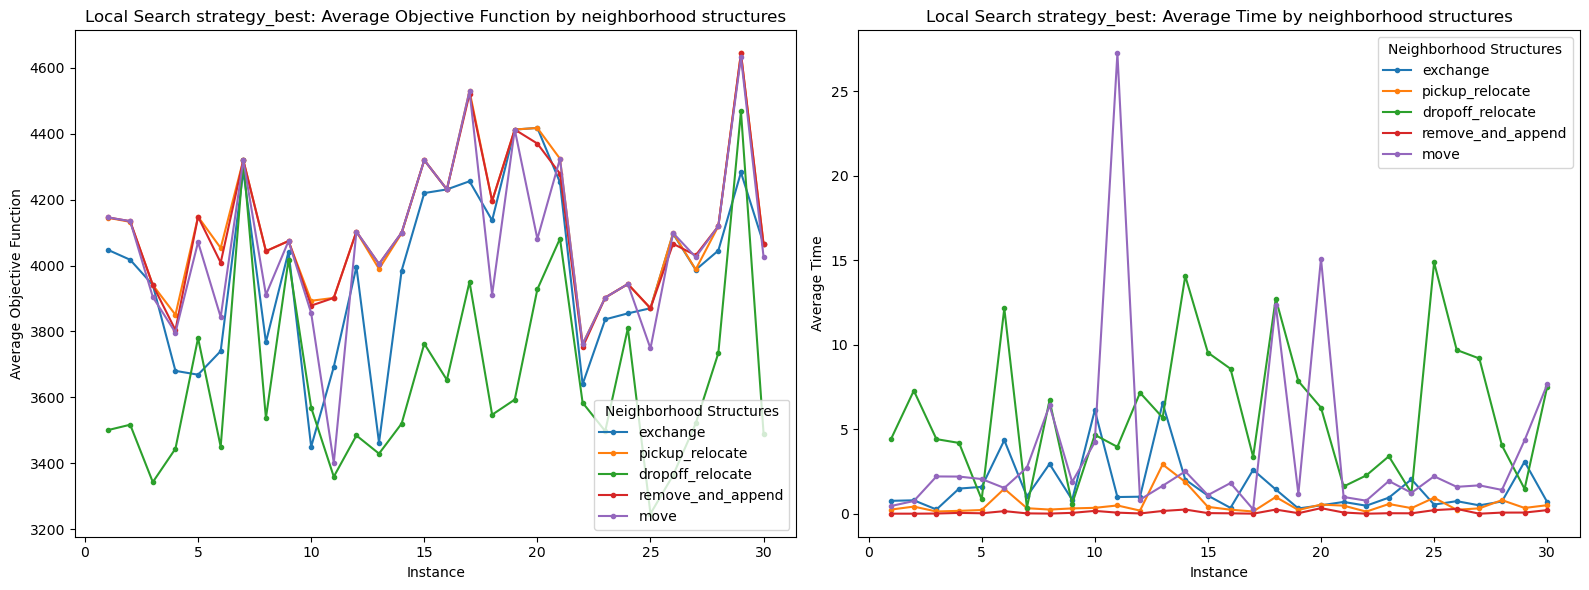

In [81]:
compare_obj_value_time_for_diff_algorithm_types_subplots(df_ls, "Local Search", 100, "neighborhood structures", 'strategy', "best")

### Compare Average Objective Funciton, Run Time for 50 customers: Different Neighborhood Structures

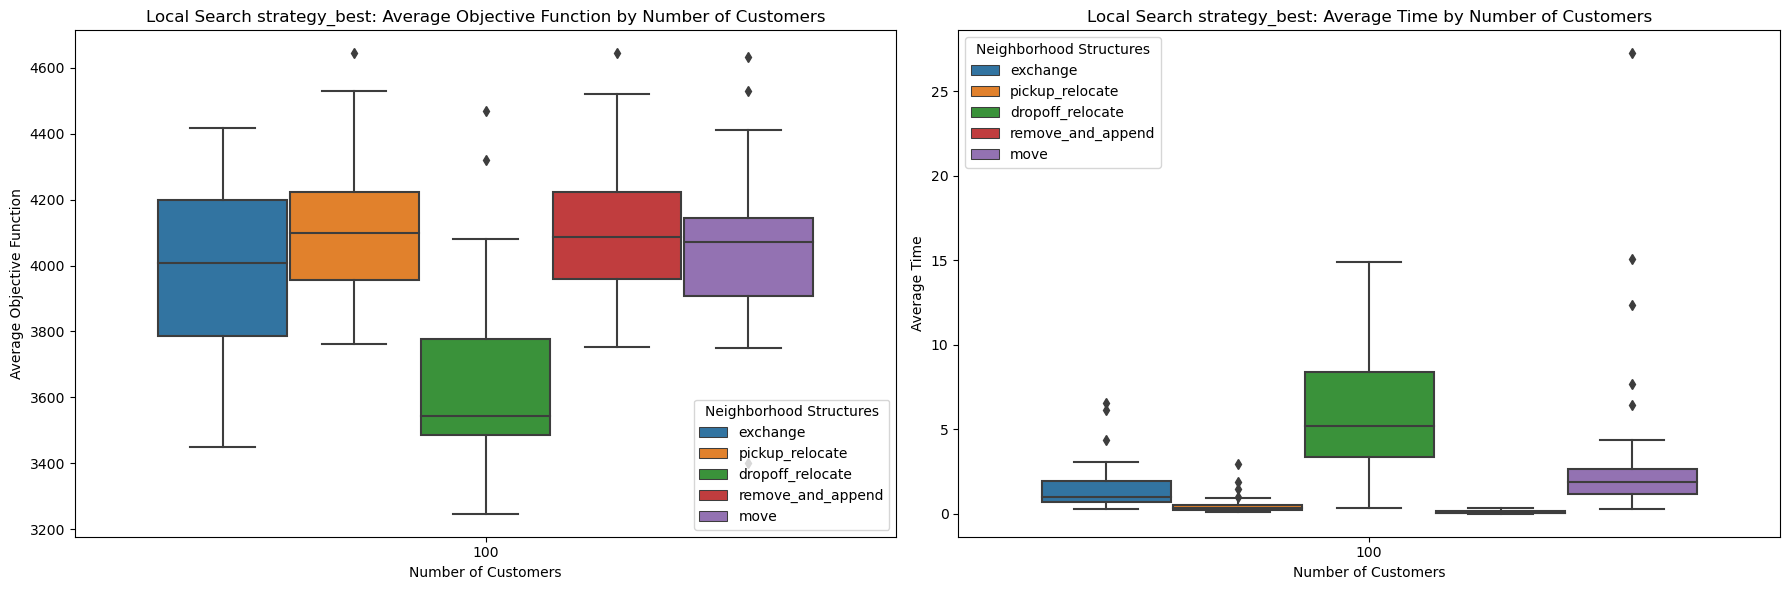

In [82]:
compare_obj_value_time_for_diff_algorithm_types_boxplots(df_ls[df_ls["nreq"] == 100], "Local Search", "neighborhood structures", 'strategy', "best")

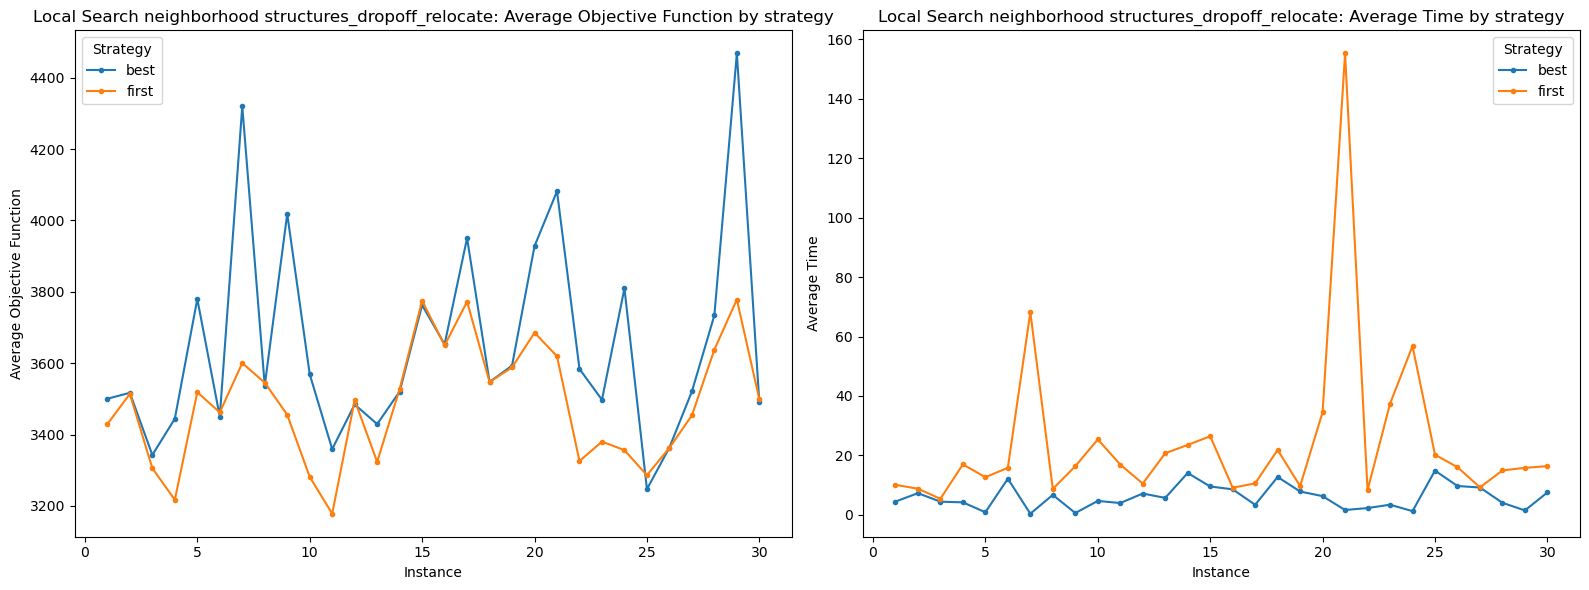

In [85]:
list_nh = ['exchange', 'pickup_relocate', 'dropoff_relocate', 'remove_and_append', 'move']
compare_obj_value_time_for_diff_algorithm_types_subplots(df_ls, "Local Search", 100, "strategy", 'neighborhood structures', "dropoff_relocate")

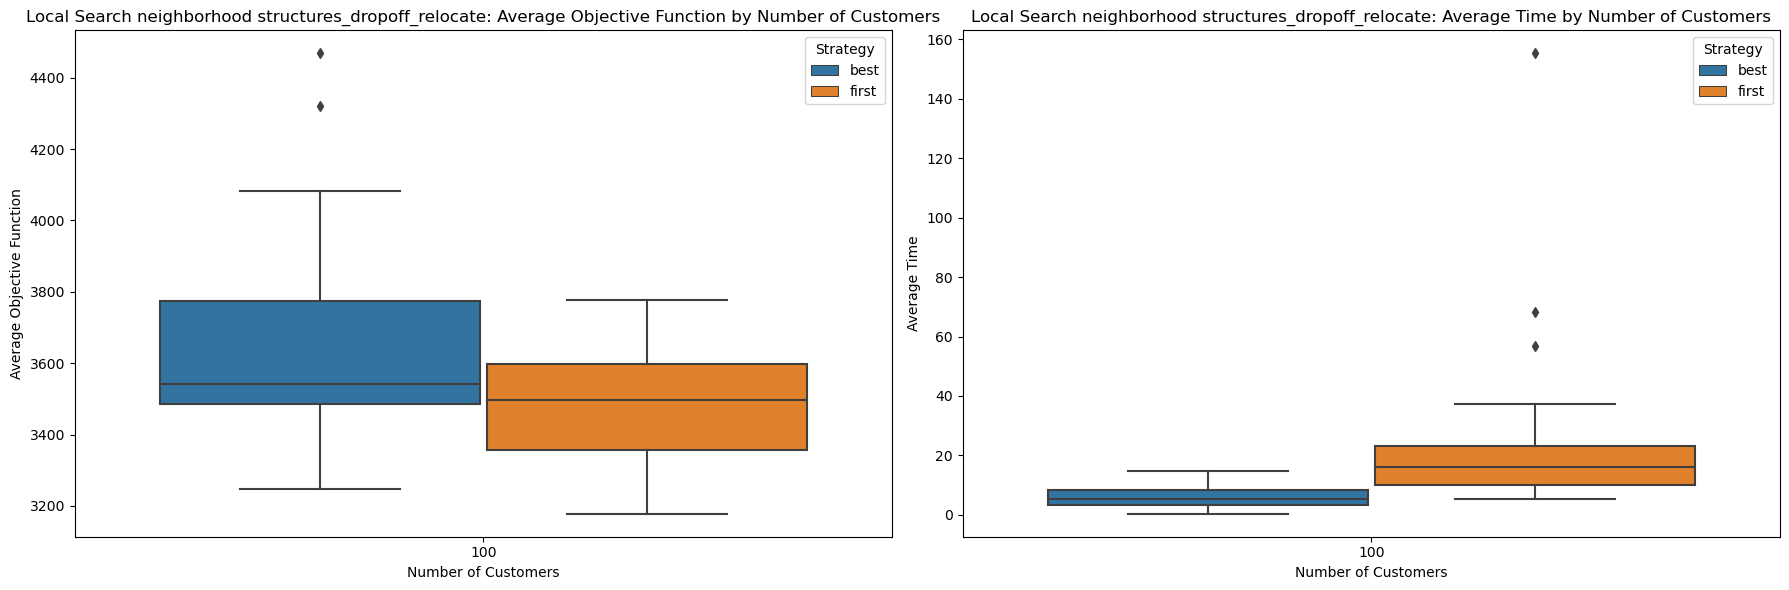

In [86]:
compare_obj_value_time_for_diff_algorithm_types_boxplots(df_ls[df_ls["nreq"] == 100], "Local Search", "strategy", 'neighborhood structures', "dropoff_relocate")

In [199]:
df_vnd = concat_dfs("vnd", ["first", "best"])
display(df_vnd)

,number,nreq,nveh,to_fulfilled,rho,avg_time,avg_obj_func,iterations,type,algorithm
0,1,50,2,50,25.94,16.247992,1219.97,135.0,first,vnd
1,2,50,2,45,35.31,7.158556,1020.22,114.0,first,vnd
2,3,50,2,45,41.17,27.536512,1076.24,136.0,first,vnd
3,4,50,2,47,70.70,33.993761,1193.35,98.0,first,vnd
4,5,50,2,45,54.30,10.522317,1019.15,117.0,first,vnd
...,...,...,...,...,...,...,...,...,...,...
115,26,100,2,89,64.14,38.718508,2569.07,94.0,best,vnd
116,27,100,2,91,25.94,27.779704,2506.97,112.0,best,vnd
117,28,100,2,91,37.19,56.592973,2661.18,97.0,best,vnd
118,29,100,2,96,52.11,20.931454,3946.64,24.0,best,vnd


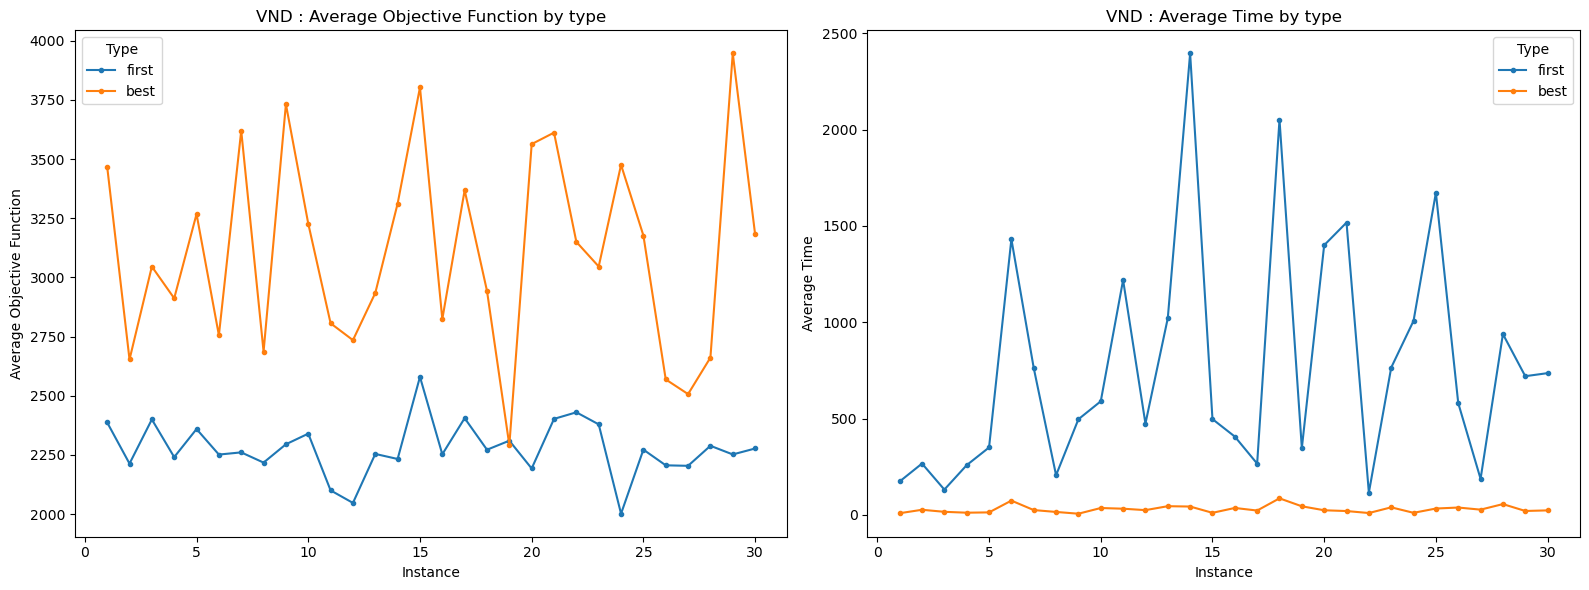

In [87]:
compare_obj_value_time_for_diff_algorithm_types_subplots(df_vnd, "VND", 100, "type")

In [200]:
file_path = f"./results/grasp/output.csv"
grasp = pd.read_csv(file_path)
grasp["type"] = None
grasp["algorithm"] = "grasp"
df_vnd_filtered = df_vnd[df_vnd["type"] == "best"]
df_const_ps = pd.concat([df_vnd_filtered, grasp], ignore_index=True)
display(df_vnd_filtered)

,number,nreq,nveh,to_fulfilled,rho,avg_time,avg_obj_func,iterations,type,algorithm
60,1,50,2,50,25.94,0.622261,1679.95,4.0,best,vnd
61,2,50,2,45,35.31,2.238041,1089.73,43.0,best,vnd
62,3,50,2,45,41.17,1.741320,1363.92,22.0,best,vnd
63,4,50,2,47,70.70,4.444289,1248.35,29.0,best,vnd
64,5,50,2,45,54.30,1.927068,1178.15,28.0,best,vnd
65,6,50,2,46,42.27,0.749650,1425.13,13.0,best,vnd
66,7,50,2,45,25.94,3.107954,1264.48,39.0,best,vnd
67,8,50,2,43,68.52,3.640153,1160.33,59.0,best,vnd
68,9,50,2,43,66.33,2.014315,949.16,53.0,best,vnd
69,10,50,2,46,25.94,3.069366,1133.52,33.0,best,vnd


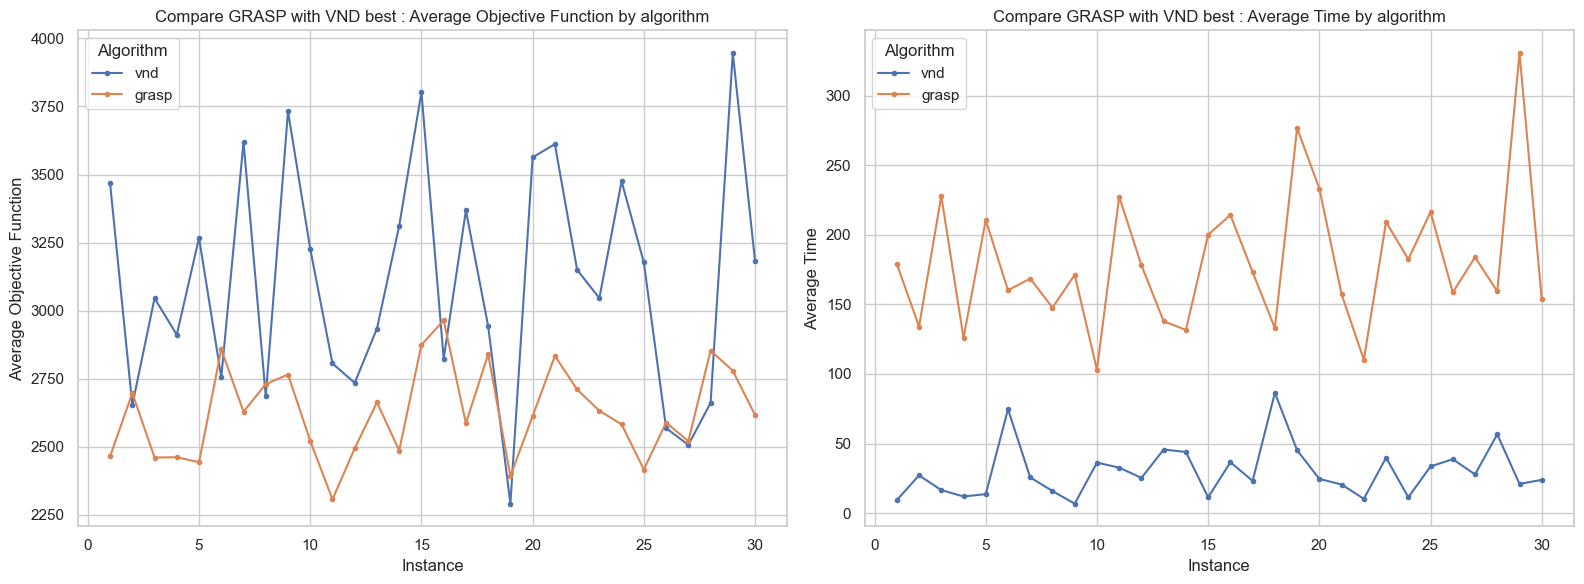

In [203]:
compare_obj_value_time_for_diff_algorithm_types_subplots(df_const_ps, "Compare GRASP with VND best", 100, "algorithm")

### Compare Average Objective Funciton, Run Time for 50 customers: Different Strategies

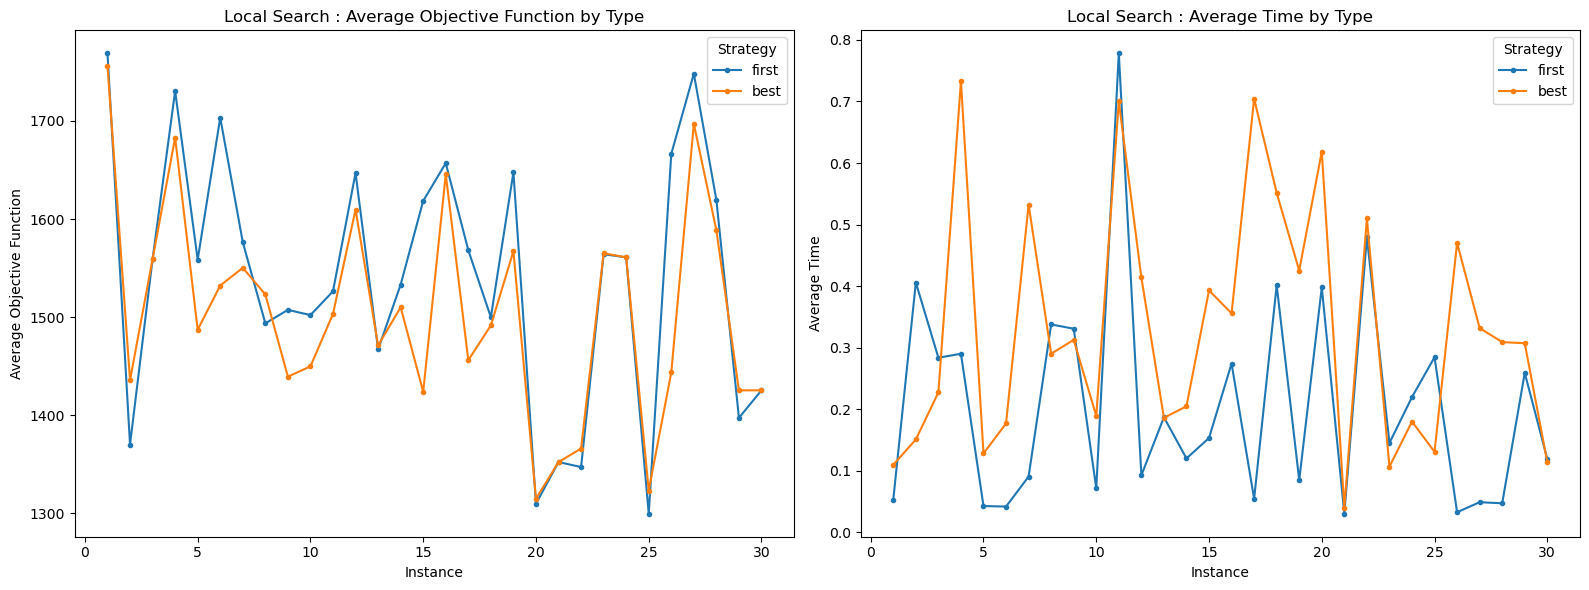

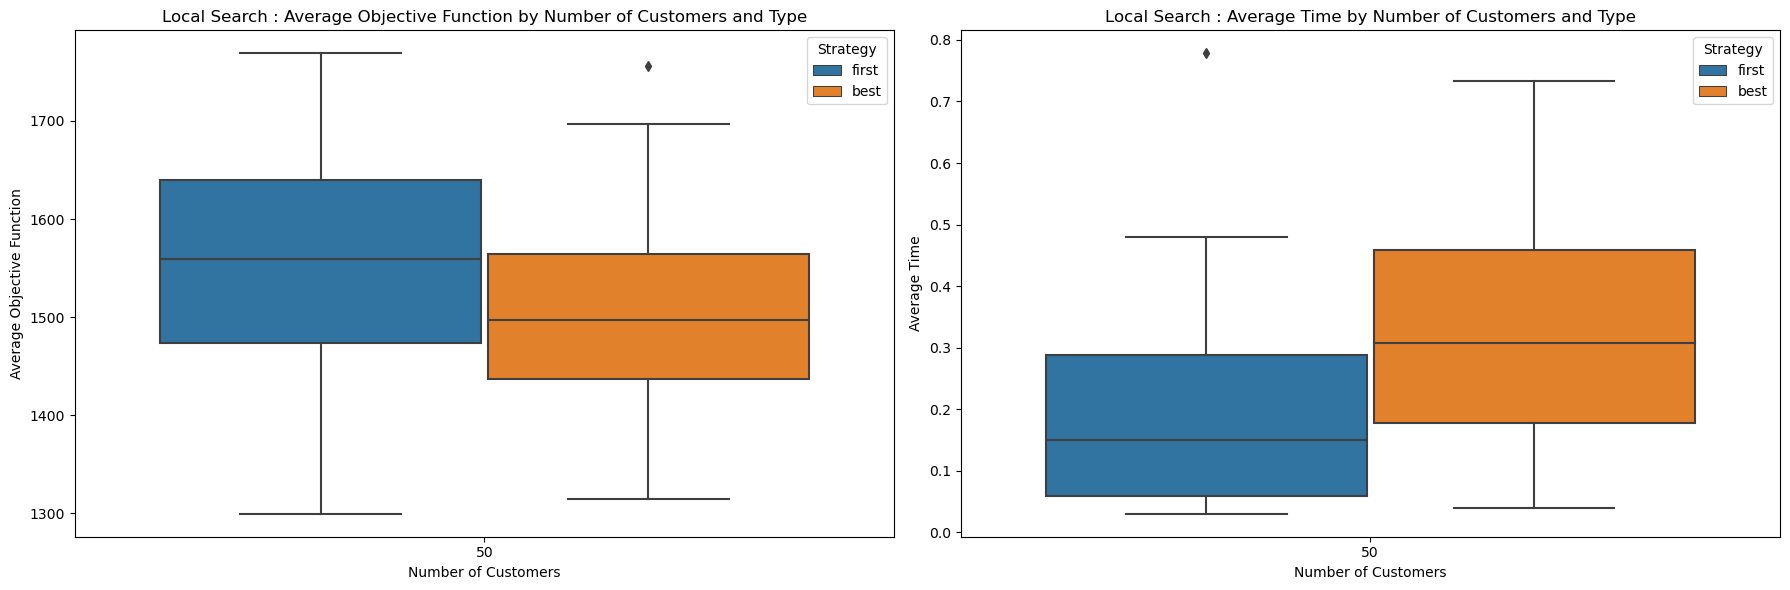

In [60]:
df_ls_str = df_ls[df_ls["neighborhood structures"] == "dropoff_relocate"].copy() 
compare_obj_value_time_for_diff_algorithm_types_subplots(df_ls_str, "Local Search", 50, "strategy")
compare_obj_value_time_for_diff_algorithm_types_boxplots(df_ls_str[df_ls_str["nreq"] == 50], "Local Search", "strategy")

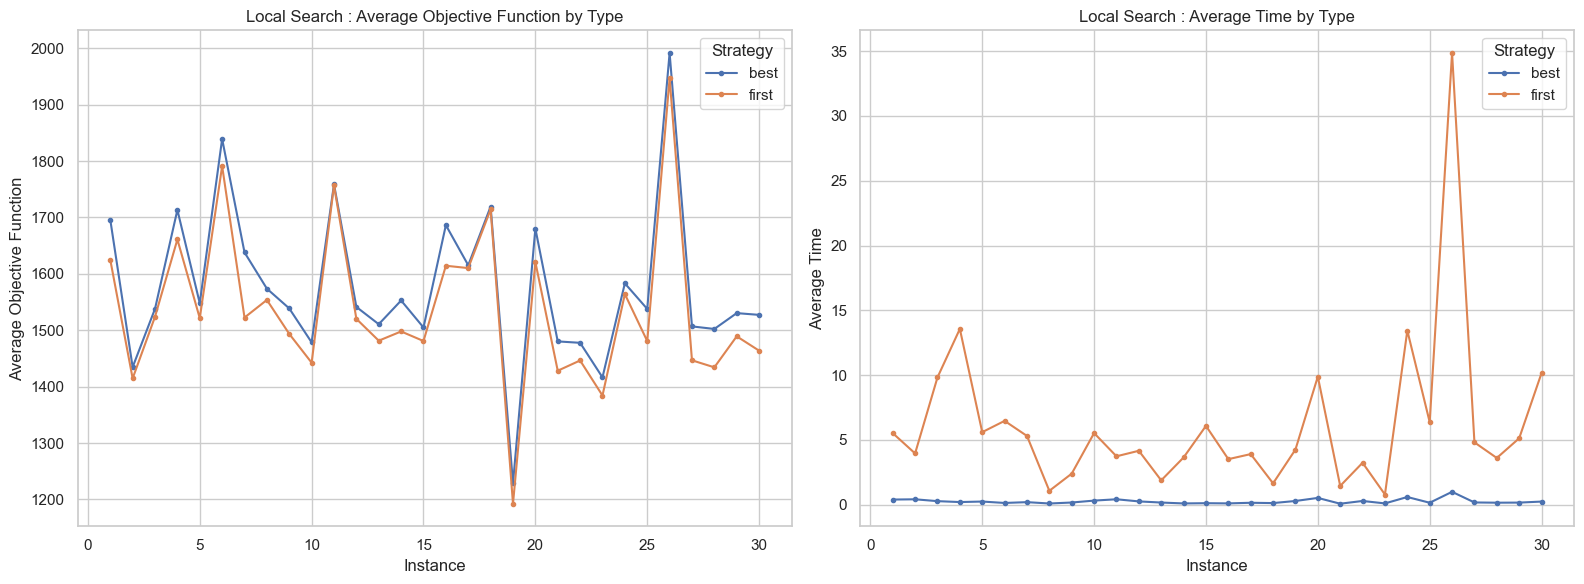

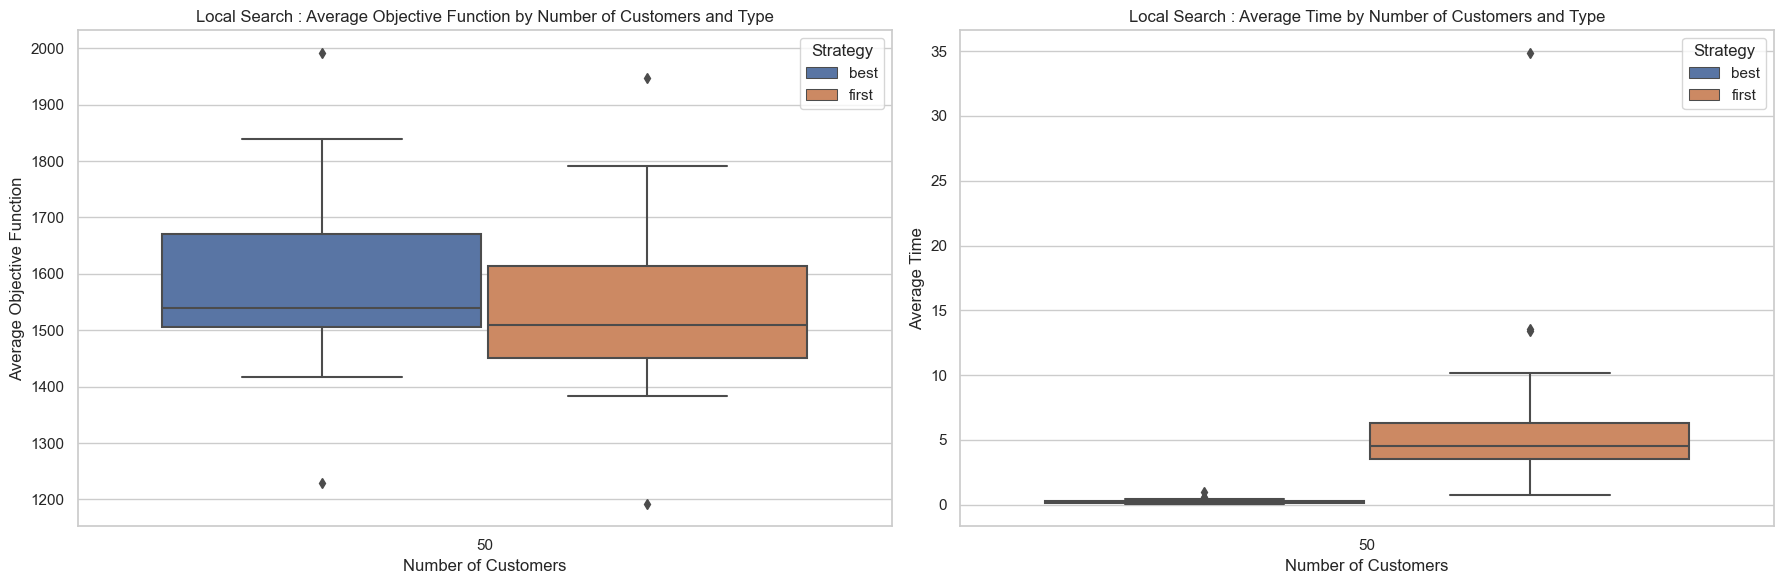

In [189]:
df_ls_str = df_ls[df_ls["neighborhood structures"] == "pickup_relocate"].copy() 
compare_obj_value_time_for_diff_algorithm_types_subplots(df_ls_str, "Local Search", 50, "strategy")
compare_obj_value_time_for_diff_algorithm_types_boxplots(df_ls_str[df_ls_str["nreq"] == 50], "Local Search", "strategy")

TODO: Perform some experimental manual tuning of relevant algorithmic parameters to find sensible parameter settings for your final experiments. Relevant parameters may be related to the degree of
randomization, neighborhood structure sizes, probabilities for the random step function in composite neighborhood structures, the cooling schedule.
Report the impact of a number of different settings on the solution quality of a selected meaningful
subset of instances.

## Simulated Annealing 

In [128]:
file_path = f"./results/sa/output.csv"
df_sa = concat_dfs("sa", ["geometric", "linear", "power", "adaptive"])
df_sa = df_sa[df_sa["nreq"] == 50]
display(df_sa)

,number,nreq,nveh,to_fulfilled,rho,avg_time,avg_obj_func,iterations,type,algorithm
0,1,50,2,48,60.86,75.140396,1343.42,10000.0,geometric,sa
1,2,50,2,45,16.88,257.885189,1077.63,10000.0,geometric,sa
2,3,50,2,46,47.73,314.270335,1096.65,10000.0,geometric,sa
3,4,50,2,47,66.33,147.672033,1273.60,6120.0,geometric,sa
4,5,50,2,45,60.86,171.845570,1150.10,8568.0,geometric,sa
...,...,...,...,...,...,...,...,...,...,...
115,26,50,2,47,27.81,301.664066,1619.13,6732.0,adaptive,sa
116,27,50,2,43,29.69,79.452838,1111.75,5814.0,adaptive,sa
117,28,50,2,41,37.19,95.724594,990.04,7344.0,adaptive,sa
118,29,50,2,45,80.90,185.909250,1226.07,10000.0,adaptive,sa


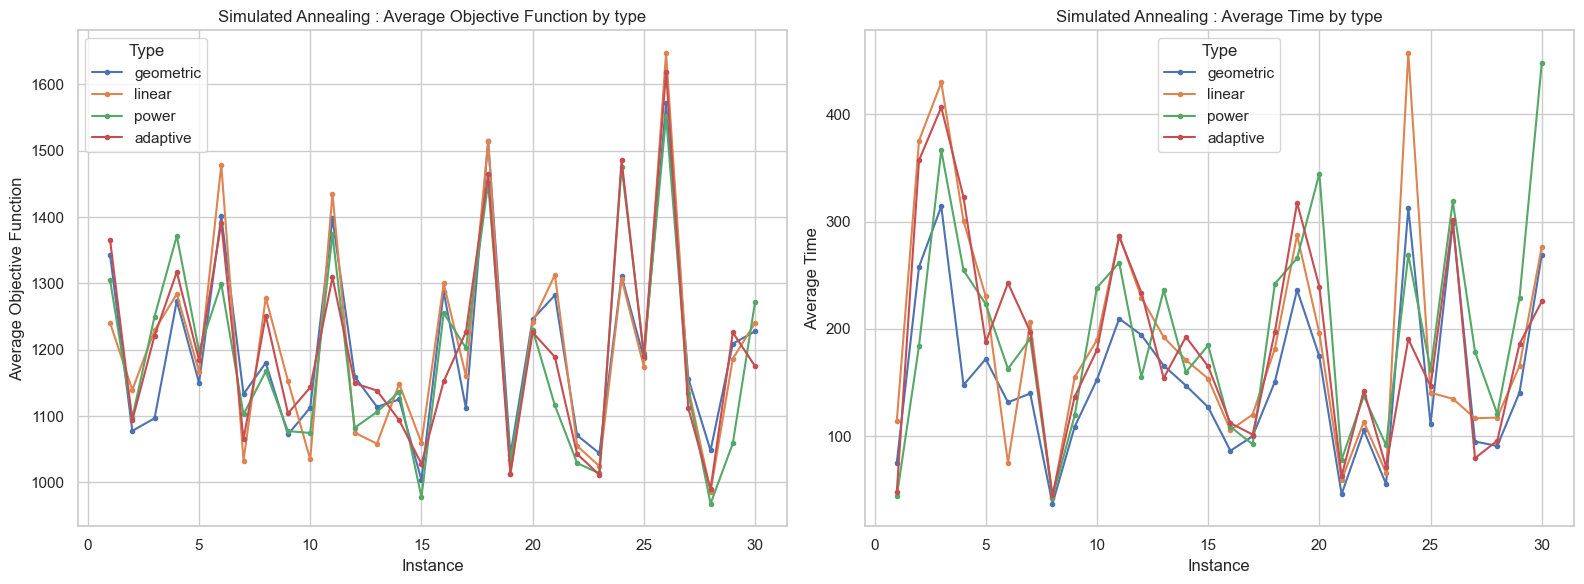

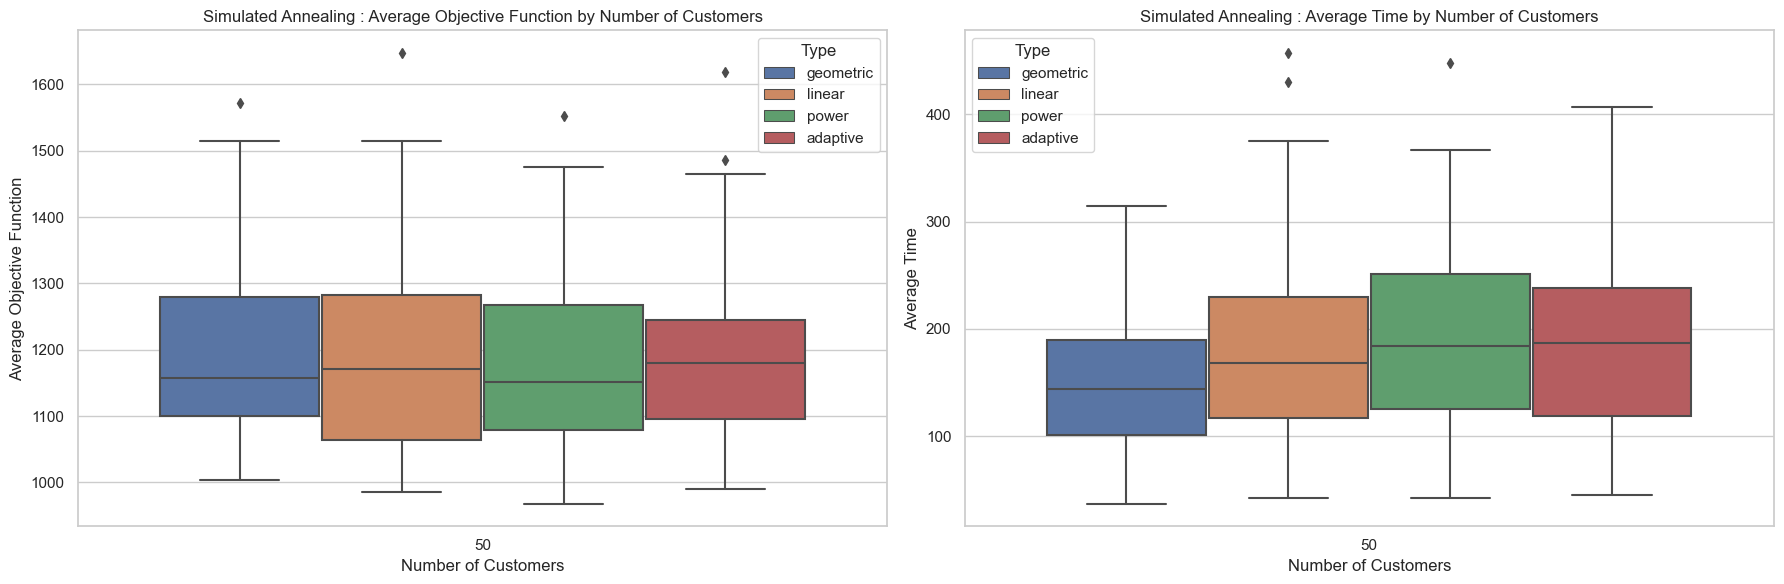

In [129]:
compare_obj_value_time_for_diff_algorithm_types_subplots(df_sa, "Simulated Annealing", 50, "type")
compare_obj_value_time_for_diff_algorithm_types_boxplots(df_sa, "Simulated Annealing", "type")

In [115]:
file_path = f"./results/sa/output.csv"
df_sa_to_combine = pd.read_csv(file_path)
df_sa_to_combine["type"] = None
df_sa_to_combine["algorithm"] = "sa"
display(df_sa_to_combine)

,number,nreq,nveh,to_fulfilled,rho,avg_time,avg_obj_func,iterations,type,algorithm
0,1,50,2,50,25.94,21.470211,1525.394,5691.6,None,sa
1,2,50,2,45,35.31,25.840141,1134.842,10000.0,None,sa
2,3,50,2,45,41.17,51.676552,1236.424,9324.4,None,sa
3,4,50,2,47,70.70,83.804122,1439.032,9224.0,None,sa
4,5,50,2,45,54.30,27.029147,1233.078,10000.0,None,sa
5,6,50,2,46,42.27,11.357820,1236.596,9774.8,None,sa
6,7,50,2,45,25.94,64.932833,1129.716,10000.0,None,sa
7,8,50,2,43,68.52,57.601726,1096.146,9897.2,None,sa
8,9,50,2,43,66.33,26.019022,1143.178,9958.4,None,sa
9,10,50,2,46,25.94,37.045621,1204.832,8262.0,None,sa


## Compare All Algorithms

In [123]:
def plot_avg_obj_func(df):

    # Unique nreq values → one plot per nreq
    unique_nreqs = sorted(df['nreq'].unique())
    n_plots = len(unique_nreqs)
    n_cols = 2
    n_rows = math.ceil(n_plots / n_cols)

    sns.set(style="whitegrid")
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows), squeeze=False)

    # Colors per algorithm (automatic)
    algorithms = sorted(df['algorithm'].unique())
    palette = sns.color_palette("tab10", len(algorithms))
    algo_colors = dict(zip(algorithms, palette))

    # ---- Build plots ----
    for idx, nreq in enumerate(unique_nreqs):
        row, col = divmod(idx, n_cols)
        ax = axes[row][col]
        sub = df[df['nreq'] == nreq].copy()

        ax.set_title(f"Number of customers = {nreq}")
        ax.set_xlabel("Instance")
        ax.set_ylabel("Average Objective Funciton")

        # Draw one curve per algorithm
        for algo in algorithms:
            df_algo = sub[sub['algorithm'] == algo]

            if df_algo.empty:
                continue

            df_algo = df_algo.sort_values("number")

            ax.plot(
                df_algo["number"],
                df_algo["avg_obj_func"],
                marker=".",
                label=algo,
                color=algo_colors[algo]
            )

        ax.legend()

    # Remove unused axes
    for idx in range(n_plots, n_rows * n_cols):
        row, col = divmod(idx, n_cols)
        fig.delaxes(axes[row][col])

    plt.tight_layout()
    plt.show()
    

In [122]:
def compare_obj_value_time_for_diff_algorithm_types_boxplots_per_nreq(
    df_all, name, legend_col, display_by_column=None, display_by_column_value=None
):
    """
    Create separate boxplots of avg_obj_func and avg_time for each 'nreq',
    with boxes grouped by `legend_col` (e.g., type or strategy).
    """
    df_plot = df_all.copy()

    # Optional filtering
    append_title = ""
    if display_by_column and display_by_column_value:
        df_plot = df_plot[df_plot[display_by_column] == display_by_column_value]
        append_title = f"{display_by_column}_{display_by_column_value}"

    # Unique number of customers
    unique_nreqs = sorted(df_plot["nreq"].unique())

    for nreq in unique_nreqs:
        sub = df_plot[df_plot["nreq"] == nreq]

        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        metrics = [
            ("avg_obj_func", "Average Objective Function"),
            ("avg_time", "Average Time")
        ]

        for ax, (metric, ylabel) in zip(axes, metrics):
            sns.boxplot(
                x=legend_col,
                y=metric,
                data=sub,
                hue=legend_col,
                ax=ax,
                palette="tab10"
            )
            ax.set_xlabel(legend_col.title())
            ax.set_ylabel(ylabel)
            ax.set_title(f"{name} {append_title} (number of customers={nreq}): {ylabel}")
            ax.legend(title=legend_col.title())

        plt.tight_layout()
        plt.show()

# TODO combine all dfs

In [144]:
df_ls_filtered = df_ls[(df_ls["neighborhood structures"] == "dropoff_relocate") & (df_ls["strategy"] == "first")]
df_vnd_filtered = df_vnd[df_vnd["type"] == "first"]
df_construction_filtered = df_construction[df_construction["type"] == "with_reordering"]
df_construction_random_filtered = df_construction_random[df_construction_random["type"] == "with_reordering"]

In [145]:
df_all = pd.concat([df_construction_filtered, df_construction_random_filtered, df_ls_filtered, df_ps, df_vnd_filtered, grasp ,df_sa_to_combine], ignore_index=True)

In [146]:
print(df_all['algorithm'].unique())

['c' 'rc' 'ls' 'ps' 'vnd' 'grasp' 'sa']


In [147]:
display(df_all)

,number,nreq,nveh,to_fulfilled,rho,avg_time,avg_obj_func,iterations,type,algorithm,neighborhood structures,strategy
0,1,50,2,50,25.94,0.849102,1768.840,48.0,with_reordering,c,NaN,NaN
1,2,50,2,45,35.31,0.528789,1543.270,44.0,with_reordering,c,NaN,NaN
2,3,50,2,45,41.17,0.409304,1721.770,44.0,with_reordering,c,NaN,NaN
3,4,50,2,47,70.70,0.561763,1831.390,46.0,with_reordering,c,NaN,NaN
4,5,50,2,45,54.30,0.449040,1558.500,43.0,with_reordering,c,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
385,26,100,2,89,64.14,269.470943,2809.876,10000.0,None,sa,NaN,NaN
386,27,100,2,91,25.94,63.336173,3100.320,10000.0,None,sa,NaN,NaN
387,28,100,2,91,37.19,342.664861,3153.960,10000.0,None,sa,NaN,NaN
388,29,100,2,96,52.11,218.643191,3498.568,10000.0,None,sa,NaN,NaN


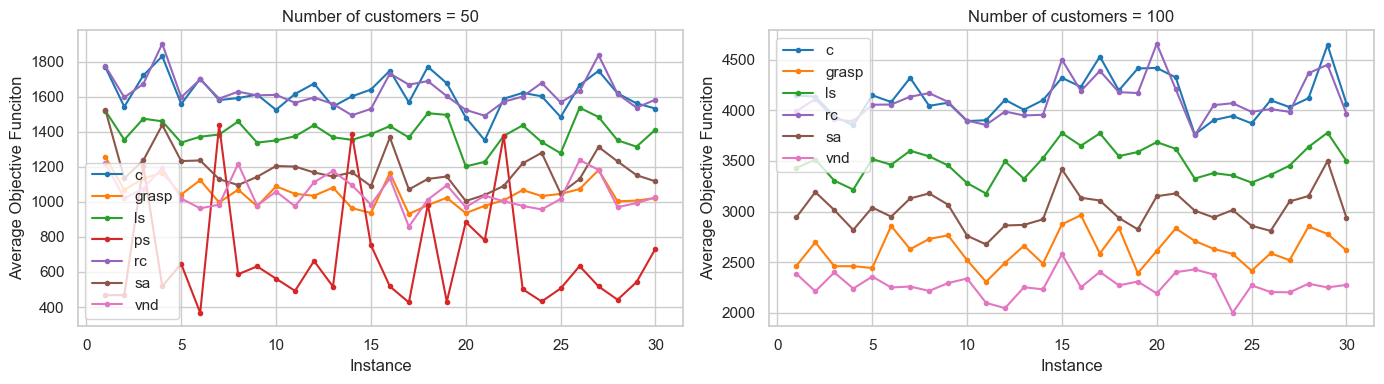

In [148]:
plot_avg_obj_func(df_all)

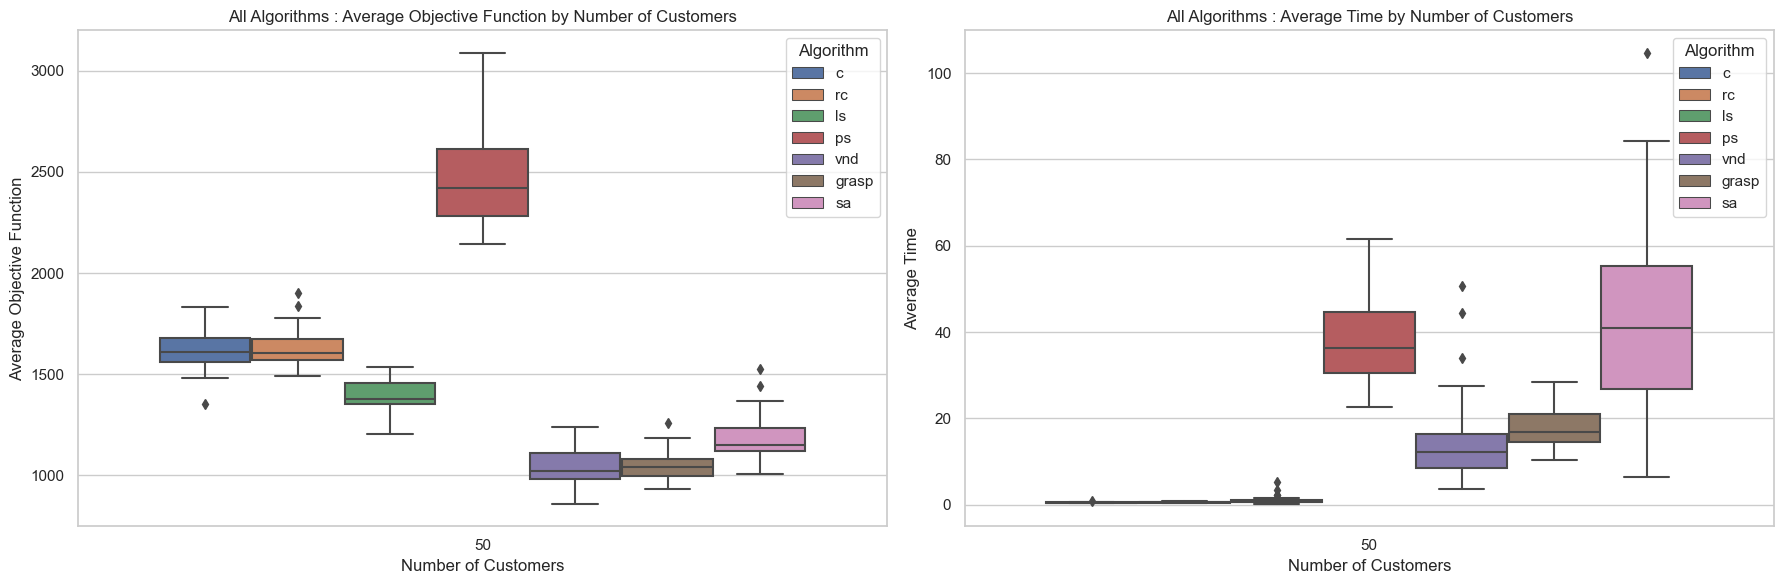

In [125]:
#compare_obj_value_time_for_diff_algorithm_types_boxplots_per_nreq(df_all, "All Algorithms", "algorithm")
compare_obj_value_time_for_diff_algorithm_types_boxplots(df_all[df_all["nreq"] == 50], "All Algorithms", "algorithm")

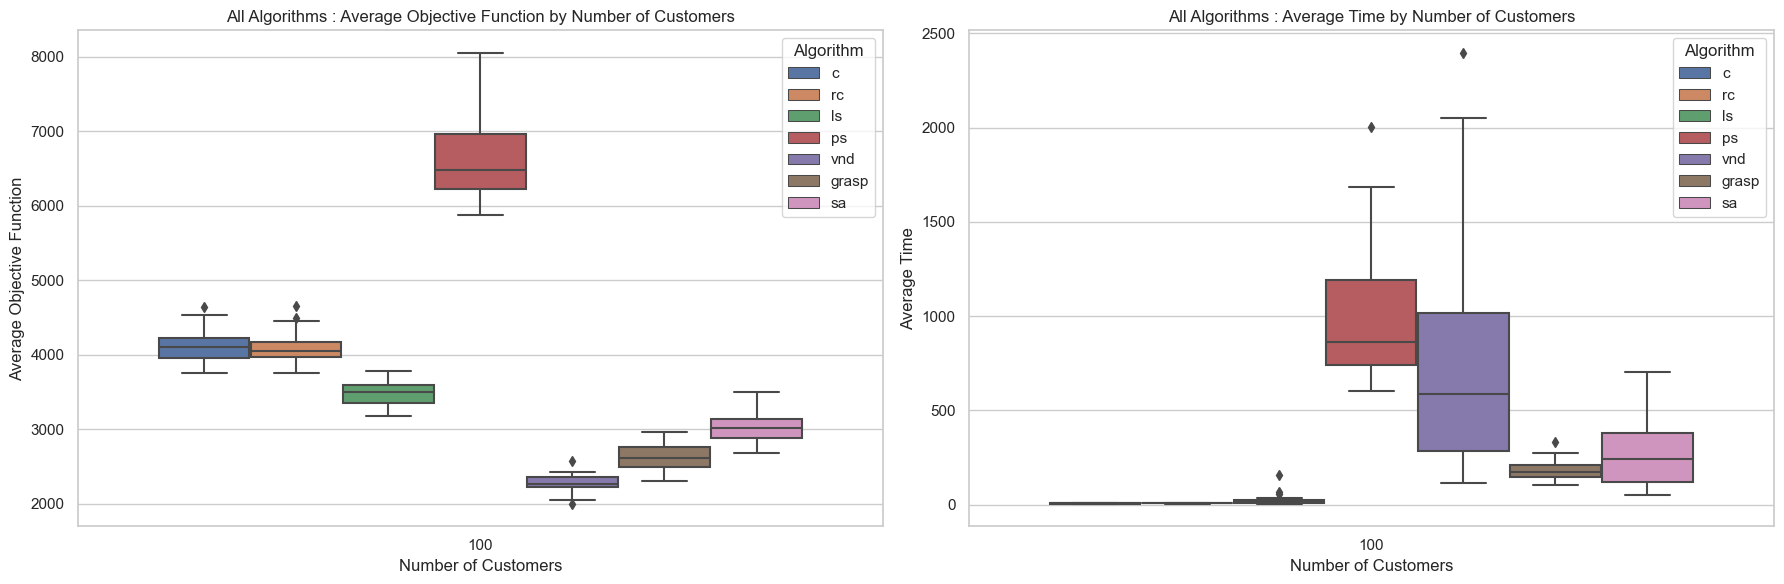

In [127]:
compare_obj_value_time_for_diff_algorithm_types_boxplots(df_all[df_all["nreq"] == 100], "All Algorithms", "algorithm")

### Progress Over Time

In [204]:
def concat_dfs_over_time(heuristic, types, c_n, file_name):
    dfs = []
    
    for t in types:
        file_path = f"./output/{heuristic}/{t}/{c_n}/test/progress_over_time/{file_name}"
        try:
            df = pd.read_csv(file_path)
            df["type"] = t
            df["algorithm"] = heuristic
            dfs.append(df)
        except FileNotFoundError:
            print(f"File not found: {file_path}")
            df = None 
    
    final_df = pd.concat(dfs, ignore_index=True)
    return final_df

In [155]:
df_construction = concat_dfs_over_time("c", ["pure", "with_reordering"], 50)
display(df_construction)

,Iteration,Objective,Fairness,Duration,type,algorithm
0,0,150.391637,0.808863,144,pure,c
1,1,203.253901,0.723269,194,pure,c
2,2,274.388219,0.659443,263,pure,c
3,3,343.577180,0.623888,331,pure,c
4,4,405.272158,0.603105,392,pure,c
...,...,...,...,...,...,...
76,36,963.295962,0.991149,963,with_reordering,c
77,37,1071.107151,0.966891,1070,with_reordering,c
78,38,1071.107151,0.966891,1070,with_reordering,c
79,39,1347.114629,0.996572,1347,with_reordering,c


In [209]:
def compare_obj_value_time_for_diff_algorithm_types_subplots(df_all, name, legend_col, display_by_column=None, display_by_column_value=None):

    append_titel=""
    if display_by_column and display_by_column_value:
        df_all = df_all[df_all[display_by_column] == display_by_column_value]
        append_titel = f"{display_by_column}_{display_by_column_value}"
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

    metrics = [
        ("Objective", "Objective"),
        ("Fairness", "Fairness")
    ]

    for ax, (value, label_part) in zip(axes, metrics):
        for t in df_all[legend_col].unique():
            subset = df_all[df_all[legend_col] == t]
            ax.plot(
                subset["Iteration"],
                subset[value],
                marker=".",
                linestyle="-",
                label=t
            )
        
        ax.set_xlabel("Iteration")
        ax.set_ylabel(label_part)
        ax.set_title(f"{name} {append_titel}: {label_part} by {legend_col.title()}")
        ax.legend(title=legend_col.title())

    plt.tight_layout()
    plt.show()

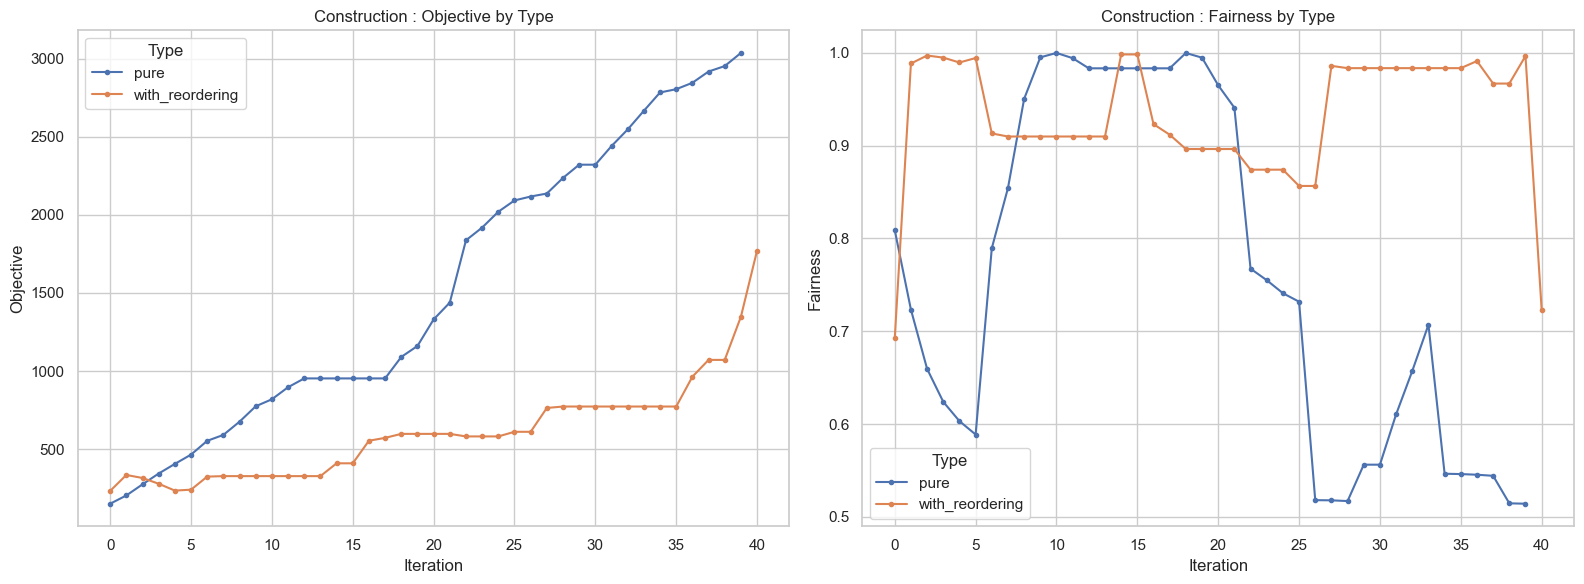

In [165]:
compare_obj_value_time_for_diff_algorithm_types_subplots(df_construction, "Construction", "type")

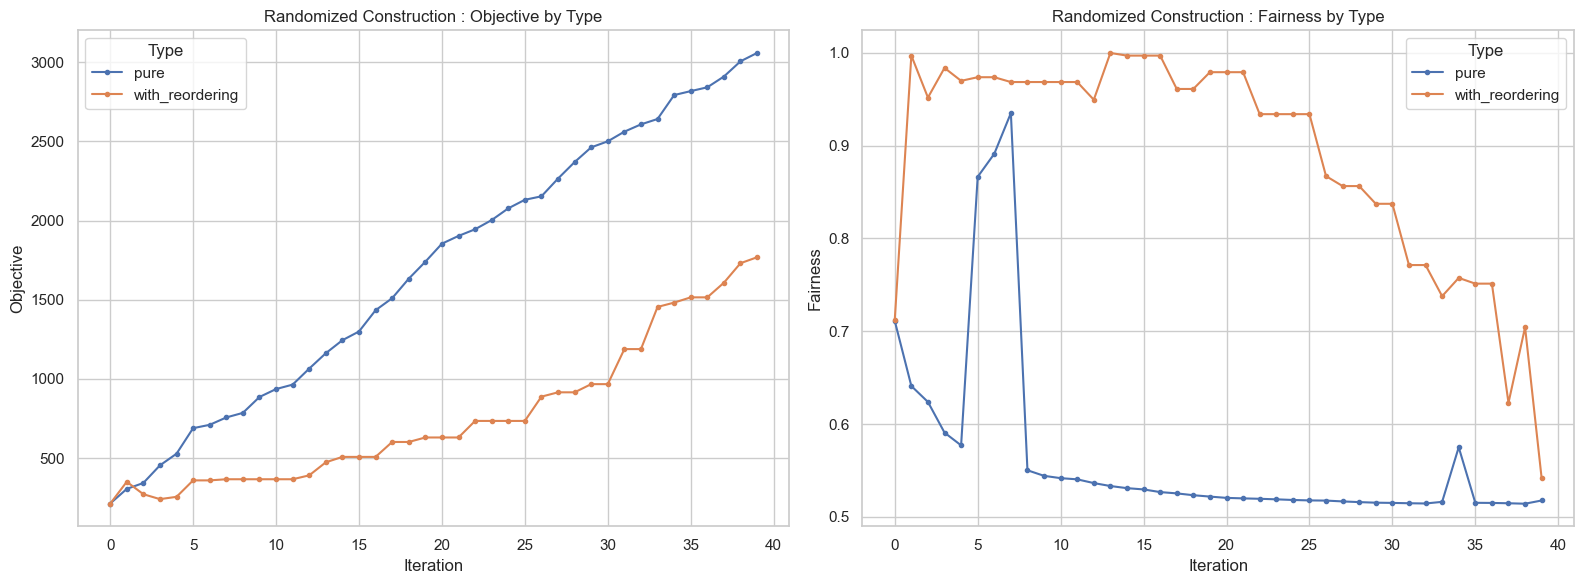

In [169]:
df_construction = concat_dfs_over_time("rc", ["pure", "with_reordering"], 50, "instance48_nreq50_nveh2_gamma42.txt_(5).csv")
compare_obj_value_time_for_diff_algorithm_types_subplots(df_construction, "Randomized Construction", "type")

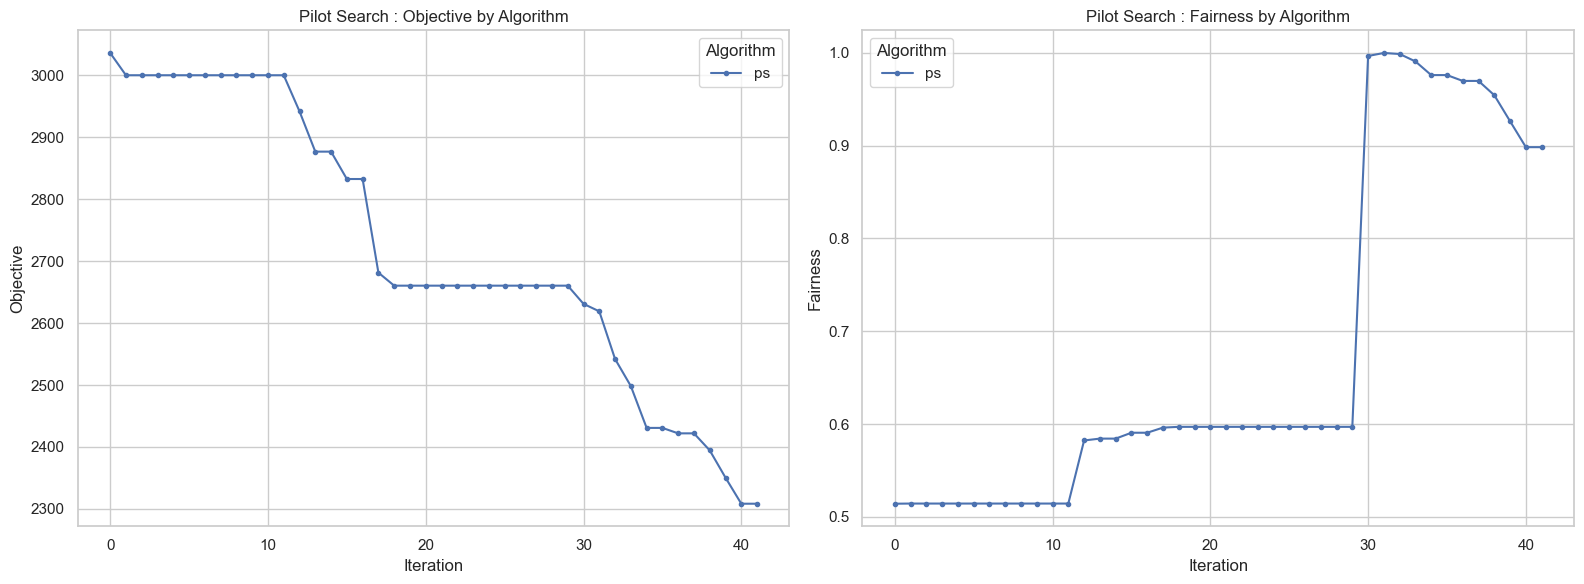

In [170]:
file_path = f"./results/ps/50/test/progress_over_time/instance48_nreq50_nveh2_gamma42.txt_(1).csv"
df_construction = pd.read_csv(file_path)
df_construction["type"] = None
df_construction["algorithm"] = "ps"
compare_obj_value_time_for_diff_algorithm_types_subplots(df_construction, "Pilot Search", "algorithm")

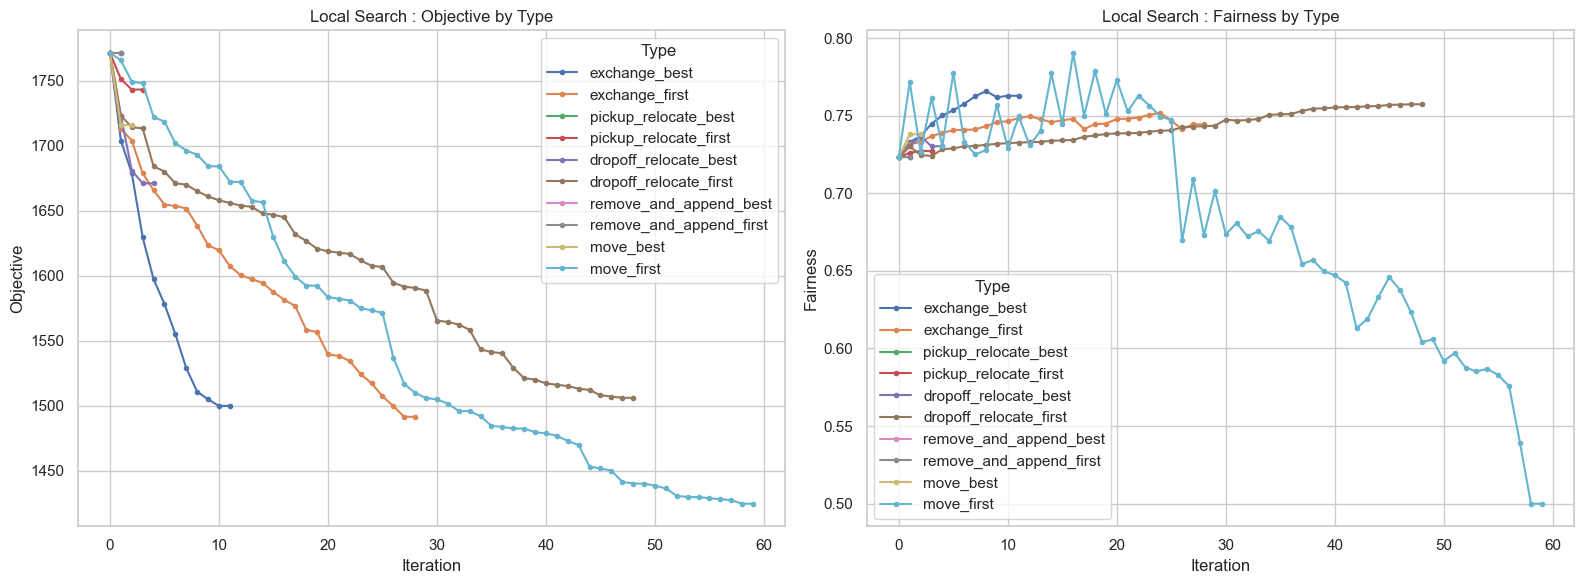

In [175]:
list_nh = ['exchange', 'pickup_relocate', 'dropoff_relocate', 'remove_and_append', 'move']
list_str = ['best', 'first']
df_ls = concat_dfs_over_time("ls", [f"{nh}_{s}" for nh in list_nh for s in list_str], 50, "instance48_nreq50_nveh2_gamma42.txt_(1).csv")
compare_obj_value_time_for_diff_algorithm_types_subplots(df_ls, "Local Search", "type")

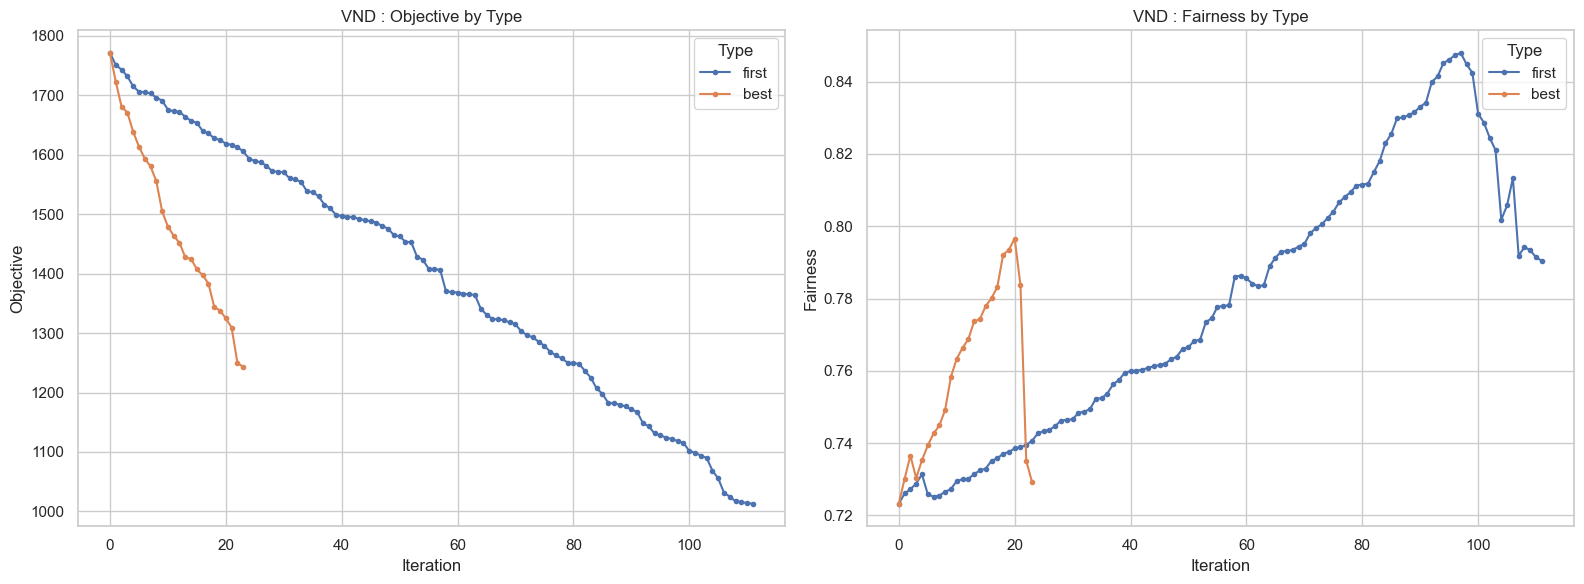

In [178]:
df_vnd = concat_dfs_over_time("vnd", ["first", "best"], 50, "instance48_nreq50_nveh2_gamma42.txt_(1).csv")
compare_obj_value_time_for_diff_algorithm_types_subplots(df_vnd, "VND", "type")

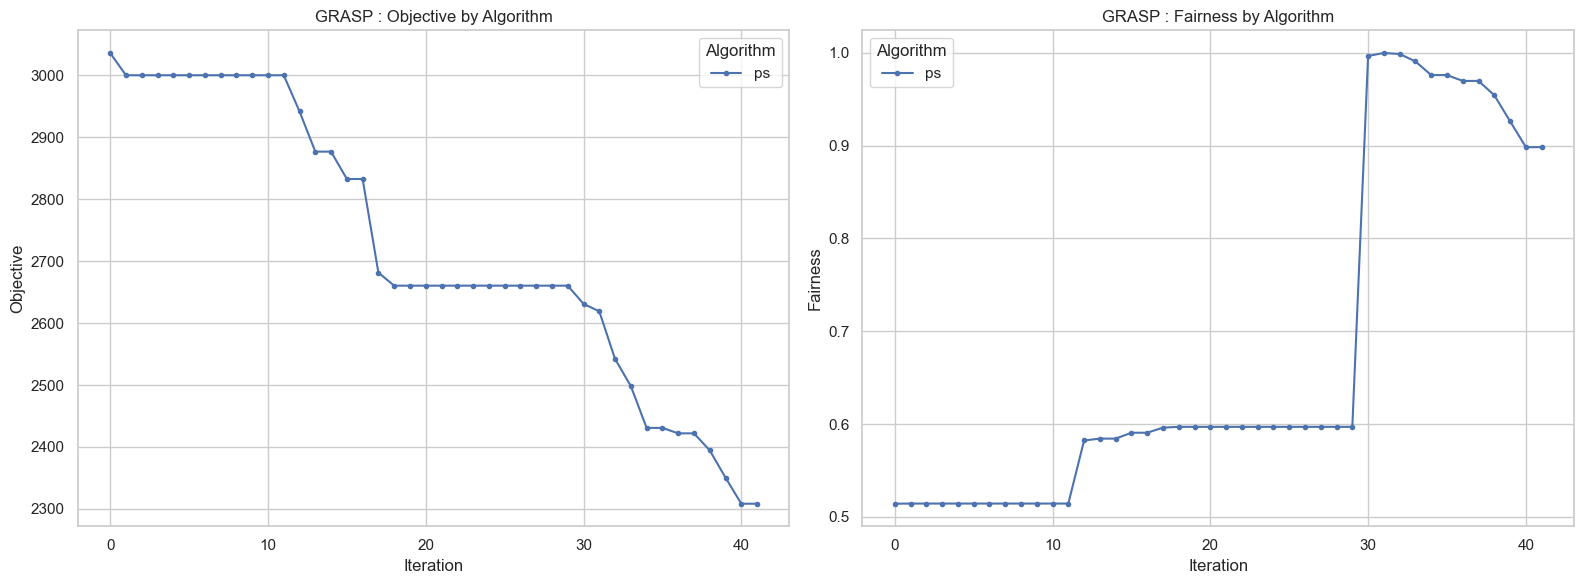

In [180]:
file_path = f"./results/grasp/50/test/progress_over_time/instance48_nreq50_nveh2_gamma42.txt_(3).csv"
grasp = pd.read_csv(file_path)
grasp["type"] = None
grasp["algorithm"] = "grasp"
compare_obj_value_time_for_diff_algorithm_types_subplots(df_construction, "GRASP", "algorithm")

In [207]:
df_sa = concat_dfs_over_time("sa", ["geometric", "linear", "power", "adaptive"], 50, "instance48_nreq50_nveh2_gamma42.txt_(1).csv")
display(df_sa)

,Iteration,Objective,Fairness,Duration,type,algorithm
0,0,1771.255167,0.723231,1762,geometric,sa
1,1,1772.259849,0.723091,1763,geometric,sa
2,2,1751.160375,0.726065,1742,geometric,sa
3,3,1753.120279,0.727264,1744,geometric,sa
4,4,1753.120279,0.727264,1744,geometric,sa
...,...,...,...,...,...,...
35299,8258,1184.231385,0.753846,1176,adaptive,sa
35300,8259,1184.231385,0.753846,1176,adaptive,sa
35301,8260,1184.231385,0.753846,1176,adaptive,sa
35302,8261,1184.231385,0.753846,1176,adaptive,sa


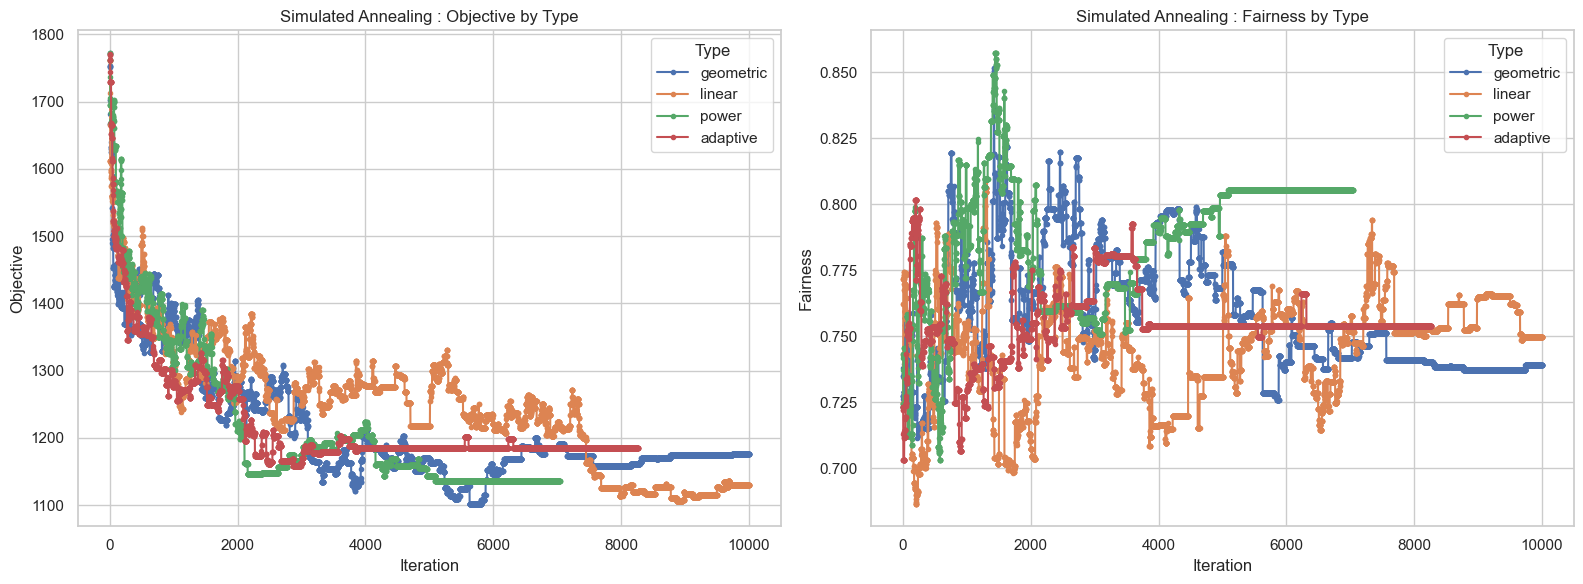

In [210]:
compare_obj_value_time_for_diff_algorithm_types_subplots(df_sa, "Simulated Annealing", "type")

### Comparison fairness measures

In [42]:
dfs = concat_dfs("aco", ["max_min", "gini", "jain"])
display(dfs)

,number,nreq,nveh,to_fulfilled,rho,avg_time,avg_obj_func,avg_max_min_length,avg_max_min_fairness,avg_max_min_customers,iterations,type,algorithm
0,1,50,2,50,25.94,22.196051,1724.305,3.325,0.730,4.880,5.5,max_min,aco
1,2,50,2,45,35.31,20.540757,1422.330,1.185,0.960,1.475,4.0,max_min,aco
2,3,50,2,45,41.17,21.838024,1432.795,1.180,0.960,1.325,3.5,max_min,aco
3,4,50,2,47,70.70,21.539477,1727.095,1.075,0.980,1.195,5.0,max_min,aco
4,5,50,2,45,54.30,19.639204,1495.600,1.075,0.980,1.100,2.0,max_min,aco
...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,26,50,2,43,66.33,20.127321,1383.690,1.115,1.000,1.050,5.0,jain,aco
86,27,50,2,46,56.48,21.290633,1657.755,1.450,0.960,1.790,7.5,jain,aco
87,28,50,2,45,25.94,20.153802,1458.425,1.290,0.985,1.340,4.5,jain,aco
88,29,50,2,45,22.19,19.954207,1408.265,3.185,0.830,3.265,4.5,jain,aco


In [43]:
def compare_obj_value_max_min_fairness(df_all, name, filter_nreq, legend_col, display_by_column=None, display_by_column_value=None):

    if filter_nreq:
        df_all = df_all[df_all['nreq'] == filter_nreq]
    append_titel=""
    if display_by_column and display_by_column_value:
        df_all = df_all[df_all[display_by_column] == display_by_column_value]
        append_titel = f"{display_by_column}_{display_by_column_value}"
    fig, axes = plt.subplots(2, 2, figsize=(16, 6), sharex=True)
    axes = axes.flatten()

    metrics = [
        ("avg_obj_func", "Average Objective Function"),
        ("avg_max_min_length", "Average Ratio of max-min path lengths"),
        ("avg_max_min_fairness", "Average fairness"),
        ("avg_max_min_customers", "Average Ratio of max-min numbers of customers")
    ]

    for ax, (value, label_part) in zip(axes, metrics):
        for t in df_all[legend_col].unique():
            subset = df_all[df_all[legend_col] == t]
            ax.plot(
                subset["number"],
                subset[value],
                marker=".",
                linestyle="-",
                label=t
            )
        
        ax.set_xlabel("Instance")
        ax.set_ylabel(label_part)
        ax.set_title(f"{name} {append_titel}: {label_part} by {legend_col}")
        ax.legend(title=legend_col.title())

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.3, hspace=0.7)
    plt.show()

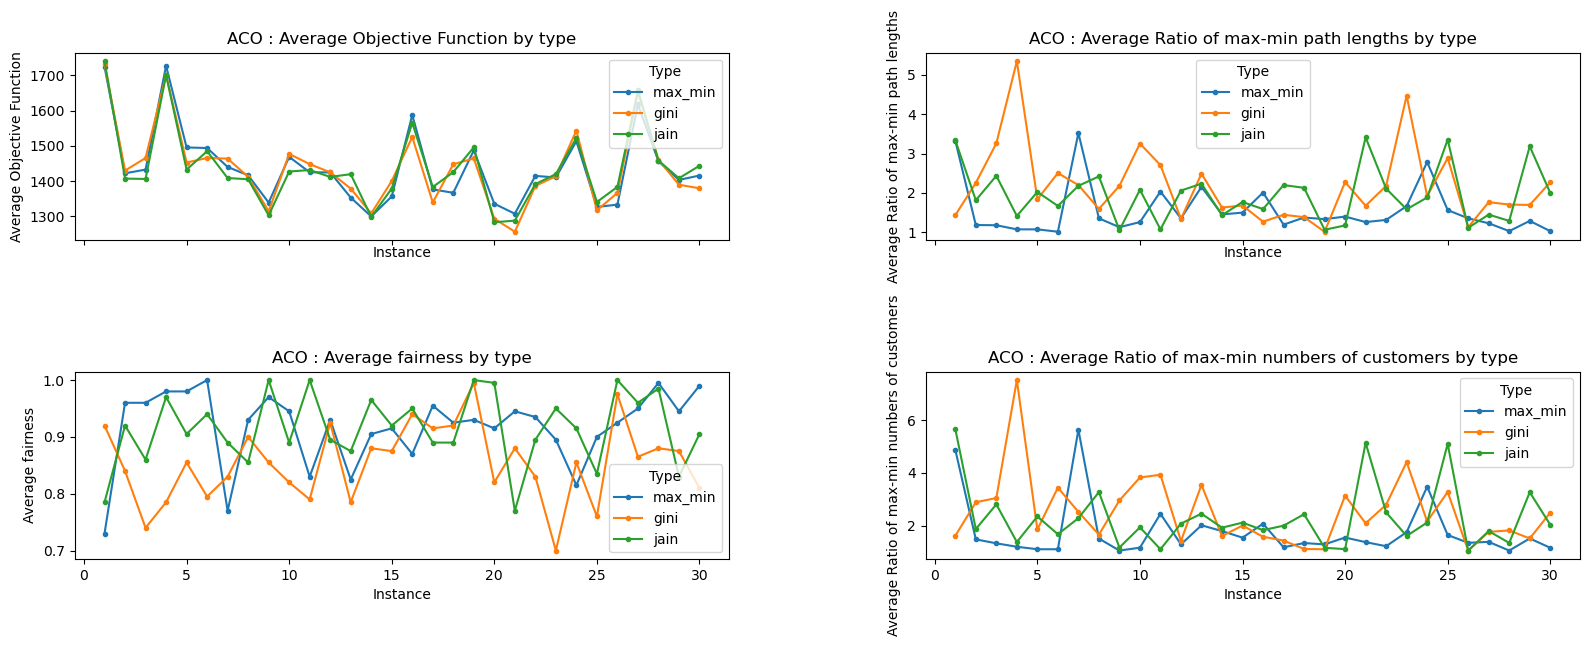

In [44]:
compare_obj_value_max_min_fairness(dfs, "ACO", 50, "type")